In [1]:
%matplotlib inline
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import traceback
import torch

import scipy
from pysindy.differentiation import SmoothedFiniteDifference

sys.path.append(r'../Invariant_Physics')
from invariant_physics.spl import *
from invariant_physics.dataset import ODE_DICT
from invariant_physics.spl.scores import *
from invariant_physics.dataset._utils import get_now_string
# from invariant_physics.dataset.dataset_mine import *
import argparse
import random
def get_train_test_total_list(train_test_total: str, num_env: int, seed=None):
    """
    Args:
        train_test_total: supports three types of argument:
            (1) one integer, like 500, indicating it's a balanced dataset;
            (2) integers split by "/", like 500/400/300/200/100. There would be an error if its length mismatches the num_env;
            (3) a string "default_x", following a built-in dict as below.
        num_env: an integer, number of environment
        seed: an integer for generating random ordering list
    Returns:
        a list of environment size, e.g., [500, 400, 300, 200, 100].
    """
    default_dic = {
        "default_0": "500/500/500/500/500",
        "default_1": "20/20/20/20/20",
        "default_2": "100/100/100/100/100",
        "default_3": "500/400/40/20/10",
        "default_4": "500/80/40/20/10",
        "default_5": "100/50/50/20/10",
        "default_6": "500/400/300/200/100",
        "default_7": "500/400/300/200/10",
        "default_8": "500/400/300/20/10",
    }

    if train_test_total.isdigit():
        train_test_total_list = [int(train_test_total) for i in range(num_env)]
    else:
        if "/" not in train_test_total:
            assert train_test_total in default_dic, "Error: key error in get_train_test_total_list: " + str(train_test_total)
            string = default_dic[train_test_total]
        else:
            string = train_test_total
        parts = string.split("/")
        train_test_total_list = [int(item) for item in parts]
    assert len(train_test_total_list) == num_env, "Error: mismatching between " + str(train_test_total) + " and " + str(num_env)
    # print(train_test_total_list)
    one_order = generate_random_order(num_env, seed)
    train_test_total_list_swapped = reseat(train_test_total_list, one_order)
    return train_test_total_list_swapped


def generate_random_order(n, seed=None):
    if seed is not None:
        random.seed(seed)
    numbers = list(range(n))
    random.shuffle(numbers)
    return numbers


def reseat(one_list, one_order):
    assert len(one_list) == len(one_order)
    return [one_list[one_order[i]] for i in range(len(one_order))]


In [2]:
train_samples, test_samples = [], []
noise_ratio = 0.0
time_spacing = "uniform"
# data_dir = f"../data_{noise_ratio}_{time_spacing}_L2/"
data_dir = f"../data"
task = "Lotka_Volterra"
# task = "Lorenz"
# task = "SIR"
# task = "Fluid_Flow"
# task = "Repressilator3"
# task = "Glycolytic_Oscillator"

task_ode_num = 1
num_env = 13    

time_string = "20240216_024249_980909" #get_now_string()
# args = argparse.Namespace(task=task, loss_func="corr",
#                           num_env=num_env, seed=0, noise_ratio=float(noise_ratio), 
#                           sample_strategy=time_spacing, params_strategy='default', 
#                           train_ratio=0.8, save_figure=1, save_folder=data_dir,
#                           train_test_total=400, train_sample_strategy="uniform",
#                           params_random_rate=0.1, y0_random_rate=0.1, dataset_gp=1,
#                           time_string=time_string)
args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                 sample_strategy='uniform', params_strategy='default', 
                 train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                 save_folder='data/', train_sample_strategy='uniform', 
                 use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=3, 
                 dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                 main_path='./',data_dir='data/')
# args.train_test_total_list = get_train_test_total_list(args.train_test_total, args.num_env, args.seed)
args.train_test_total_list = [500] * num_env

ode = ODE_DICT.get(args.task)(args)
ode.build()

save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)

info = None
with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
    info = json.load(f)

for env in range(num_env):
    trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
    tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
    trs = trs.sort_values(by='t', ascending=True)
    tes = tes.sort_values(by='t', ascending=True)
    train_samples.append(trs)
    test_samples.append(tes)
# df = pd.read_csv(os.path.join(data_dir, task_name, task_name + f'_{env}_raw.csv'))
# t_series = df.t
# t_series = t_series.to_numpy()

ode_name: Lotka_Volterra
num_env: 13
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
Environment 01: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
Environment 02: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
Environment 03: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
Environment 04: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
Environment 05: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
Environment 06: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
Environment 07: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
Environment 08: train set: 4

100%|█████████████████████████████████████████████████████████████████| 13/13 [00:01<00:00, 10.52it/s]


In [471]:
# env = 0
# ode.y[env][ode.train_indices_list[env]]

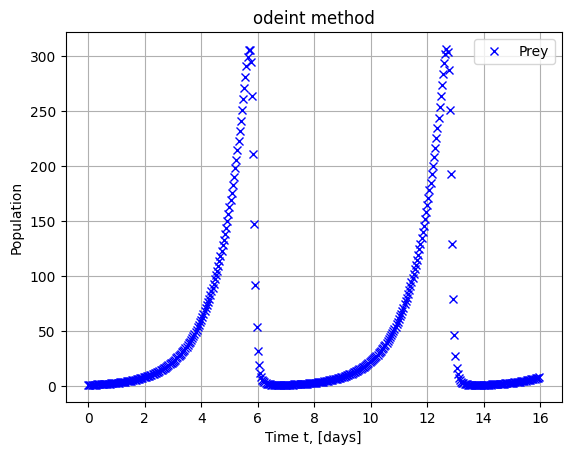

In [14]:
env = 5
# dx = 0.01
task_ode_num = 1
eps = 1#float(noise_ratio)
data = train_samples[env]
# a,b,c,d = info['params'][str(env)]
variables = list(data.columns)
first_d_idx = variables.index('d'+variables[1])
for variable in variables[:first_d_idx]:
    globals()[variable] = data[variable].to_numpy()
target_variable = variables[first_d_idx + task_ode_num - 1]
globals()['f_true'] = data[target_variable].to_numpy()
true_dx = ode._func(data[variables[1:first_d_idx]].to_numpy().T, t, env)[task_ode_num-1,:]

plt.figure()
plt.grid()
plt.title("odeint method")
train_size = x.shape[0]
# bound = train_size // (1/dx)
window_size = 50
window_num = 2.5
window_bef = int(window_size*(window_num-1))
window_aft = int(window_size*(window_num))
# plt.plot(t[window_bef:window_aft], x[window_bef:window_aft], 'xb', label = 'Prey')
# plt.plot(np.concatenate([t[:window_bef], t[window_aft:]]), 
#          np.concatenate([x[:window_bef], x[window_aft:]]), 'xg', label = 'Prey')

plt.plot(t, x, 'xb', label = 'Prey')
# plt.plot(t, y, '+g', label = 'Predator')
# plt.plot(np.arange(0,bound,0.01), train_samples[env][1,:], '+r', label = "Predator")
# plt.plot(t, f_true, 'or', label = 'Pred Deriv')
# plt.plot(t, true_dx, '-b', label = 'Prey Deriv')
# plt.plot(t, (1.656674637525512*(y-1.6154384874648506)*(x-1.1633482368694503) + -1.6863347488260283), '+g', label = 'Candidate')
# plt.plot(t, data["mean_d"+variables[task_ode_num]], '-g')
# plt.plot(t, pred_dx_spline, '-g', label = 'Pred Deriv Spline')
# plt.plot(t, pred_dx_sfd, '-y', label = 'Pred Deriv SFD')
# plt.plot(t, pred_dx_orig, '-b', label = 'Pred Deriv Orig')
plt.xlabel('Time t, [days]')
plt.ylabel('Population')
plt.legend()

plt.show()

In [7]:
from math import sqrt, pi
from typing import Callable

import numpy as np
from numpy import ndarray, newaxis

from scipy.integrate import trapz, simps
from invariant_physics.loss.integrate import trapezoid#, simpson

import torch
from torch import Tensor

def trapezoid(x: Tensor, tspan: Tensor = None, dt: float = None, dim: int = 0):
    x = torch.tensor(x)
    xT = x.transpose(0, dim)
    if dt is not None:
        assert tspan is None
        term1 = xT[1:-1].sum(dim = 0, keepdim = True)
        integ_x: Tensor = dt * (xT[0] + 2 * term1 + xT[-1]) / 2
    elif tspan is not None:
        tspan = torch.tensor(tspan)
        assert tspan.dim() == 1
        assert dt is None
        factor1 = ((xT[:,:-1] + xT[:,1:]) / 2).reshape(-1, xT.shape[0], 1)
        factor2 = (tspan[1:] - tspan[:-1]).reshape((-1,) + (1,) * (factor1.dim() - 1))
#         torch.Size([49, 400, 1]) torch.Size([399, 1, 1])
#         print(factor1.shape, factor2.shape)
        integ_x: Tensor = (factor2 * factor1).sum(dim = 0, keepdim = True)
    return integ_x.transpose(0, dim).squeeze(dim)

def simpson(x: Tensor, dt: float = None, dim: int = -1):
    x = torch.tensor(x)
#     print(x.shape)
    xT = torch.squeeze(x).transpose(0, dim)
    x_even = xT if len(xT) % 2 else xT[:-3]
    term1: Tensor = x_even[1:-1:2].sum(dim = 0, keepdim = True)
    term2: Tensor = x_even[2:-1:2].sum(dim = 0, keepdim = True)
    integ_x: Tensor = 2 * dt / 6 * (x_even[0] + 4 * term1 + 2 * term2 + x_even[-1])
    if not len(xT) % 2:
        term3 = xT[-4] + 3*xT[-3] + 3*xT[-2] + xT[-1]
        integ_x = integ_x + 3 * dt * term3 / 8
    return integ_x.transpose(0, dim).squeeze(dim)


class VF_Loss:
    '''
        Create a `VF_loss` object with specific settings. Now
        only `fourier` is supported.
        
        Args:
        - `func_num`: the number of sine functions you would like to use. 
            40~50 is recommend.
        - `func_type`: Now only `fourier` is supported.
        - `integ_method`: numerical integration method. It should be chosen from `simps` 
            and `trapz`.
            Recommendation: `simps` > `trapz`
        - `reduction`: sum or mean.
        '''
    def __init__(
        self, 
        func_num: int,  
        func_type: str = 'fourier',
        integ_method: str = 'simps',
        reduction: str = 'mean', 
    ) -> None:
        super().__init__()
        self.func_num, self.func_type = func_num, func_type
        self.integ_method = integ_method
        self.reduction = reduction
        
    def fourier_basis(self, tspan: ndarray):
        '''
        Generate sine functions.
        
        Mathematical Expressions: 
            ``g_s(t) = sqrt(2/T) sin (s*pi*t / T)``
            
        Attention: `tspan` must be `0, dt, 2dt, ..., T`.
        
        Return shape: `(func_num, len(tspan))`
        '''
        T = tspan[-1]
        s = np.arange(1, self.func_num + 1, 1.0).reshape((-1, 1))
        funcs_input = pi * s @ tspan.reshape((1, -1)) / T
        gs = sqrt(2 / T) * np.sin(funcs_input)
        dgs = pi * s / T * sqrt(2 / T) * np.cos(funcs_input)
        return gs, dgs # (func_num, len(tspan))
        
    def __call__(self, f: ndarray, X: ndarray, tspan: ndarray) -> ndarray:
        '''
        Shape of inputs:
        - `X.shape`: `(len(tspan), traj_num)`
        - `f.shape`: `(len(tspan), traj_num)`
        - `tspan`: `0, dt, 2dt, ..., T`
        '''
        return self.integ_regular(f, X, tspan)
        # tspan.shape: (len(tspan)[, traj_num])
        # if tspan.axis() == 1: return self.integ_regular(ode_func, X, tspan)
        # elif tspan.axis() == 2: return self.integ_irregular(ode_func, X, tspan)
        
    def integ_regular(self, f: ndarray, X: ndarray, tspan: ndarray) -> ndarray:
        '''
        Shape of inputs:
        - `X.shape`: `(len(tspan), traj_num)`
        - `f.shape`: `(len(tspan), traj_num)`
        - `tspan`: `0, dt, 2dt, ..., T`
        '''
        if self.func_type == 'fourier': g, dg = self.fourier_basis(tspan)
        else: raise NotImplementedError 
        # (func_num, len(tspan), traj_num)
        integrand = f * g[..., newaxis] + X * dg[..., newaxis]
        
        if self.integ_method == 'simps':
            loss_raw: ndarray = (simpson(integrand, float(tspan[1] - tspan[0]), dim = 1)**2).sum(axis = 0).numpy()
        elif self.integ_method == 'trapz':
            loss_raw: ndarray = (trapezoid(integrand, tspan, dim = 1)**2).sum(axis = 0).numpy()
        else: raise NotImplementedError 
            
#         if self.integ_method == 'simps':
#             loss_raw: ndarray = (simps(integrand, tspan, axis = 1)**2).sum(axis = 0)
#         elif self.integ_method == 'trapz':
#             loss_raw: ndarray = (trapz(integrand, tspan, axis = 1)**2).sum(axis = 0)
#         else: raise NotImplementedError 
            
        if self.reduction == 'sum': return loss_raw.sum()
        elif self.reduction == 'mean': return loss_raw.mean()
        else: raise ValueError('Reduction mode is not set correctly!')
        
def corr_func(data1, data2, window_size=10, step=None, use_abs=False):
    data_length = min(len(data1), len(data2))
    window_size = window_size if window_size < data_length else data_length
    step = step if step else window_size//2 
    data1_t = torch.from_numpy(data1).cuda().view(-1)
    data2_t = torch.from_numpy(data2).cuda().view(-1)
    x, y = data1_t.unfold(0, window_size, step), data2_t.unfold(0, window_size, step)
    mean_x = torch.mean(x, dim=1).view(-1,1)
    mean_y = torch.mean(y, dim=1).view(-1,1)
    covariance = torch.mean((x - mean_x) * (y - mean_y), dim=1)
    std_dev_x = torch.std(x, unbiased=False, dim=1)
    std_dev_y = torch.std(y, unbiased=False, dim=1)

    corrs = covariance / (std_dev_x * std_dev_y)
    if use_abs:
        corrs = torch.abs(corrs)
        
    avg_corr = torch.sum(corrs) / len(corrs)
    return avg_corr.cpu().numpy()

def trapezoid_trajectory(x: Tensor, tspan: Tensor = None, dt: float = None, dim: int = 0):
    x = torch.tensor(x)
    xT = x.transpose(0, dim)
    if dt is not None:
        assert tspan is None
        term1 = xT[1:-1].sum(dim = 0, keepdim = True)
        integ_x: Tensor = dt * (xT[0] + 2 * term1 + xT[-1]) / 2
    elif tspan is not None:
        tspan = torch.tensor(tspan)
        assert tspan.dim() == 1
        assert dt is None
        factor1 = ((xT[:,:-1] + xT[:,1:]) / 2).reshape(-1, xT.shape[0], 1)
        factor2 = (tspan[1:] - tspan[:-1]).reshape((-1,) + (1,) * (factor1.dim() - 1))
        cumulative_areas = torch.cumsum(factor2 * factor1, dim=0)
        # Prepend with a zero (or initial value) to represent the starting point of the trajectory
        initial_value = torch.zeros_like(cumulative_areas[:1])
        trajectory = torch.cat([initial_value, cumulative_areas], dim=0)
    return trajectory.view(-1)

class Corr_Loss:
    '''
        Create a `VF_loss` object with specific settings. Now
        only `fourier` is supported.
        
        Args:
        - `integ_method`: numerical integration method. It should be chosen from `simps` 
            and `trapz`.
            Recommendation: `simps` > `trapz`
        - `reduction`: sum or mean.
        '''
    def __init__(
        self, 
        integ_method: str = 'trapz',
        reduction: str = 'mean', 
        window_size: int = 21
    ) -> None:
        super().__init__()
        self.integ_method = integ_method
        self.reduction = reduction
        self.window_size = window_size
        
    def __call__(self, f: ndarray, X: ndarray, tspan: ndarray) -> ndarray:
        '''
        Shape of inputs:
        - `X.shape`: `(len(tspan), traj_num)`
        - `f.shape`: `(len(tspan), traj_num)`
        - `tspan`: `0, dt, 2dt, ..., T`
        '''
        return self.integ_regular(f, X, tspan)
        # tspan.shape: (len(tspan)[, traj_num])
        # if tspan.axis() == 1: return self.integ_regular(ode_func, X, tspan)
        # elif tspan.axis() == 2: return self.integ_irregular(ode_func, X, tspan)
        
    def integ_regular(self, f: ndarray, X: ndarray, tspan: ndarray) -> ndarray:
        '''
        Shape of inputs:
        - `X.shape`: `(len(tspan), traj_num)`
        - `f.shape`: `(len(tspan), traj_num)`
        - `tspan`: `0, dt, 2dt, ..., T`
        '''
        # (func_num, len(tspan), traj_num)
        integrand = f.reshape(1,-1,1)
        
        if self.integ_method == 'trapz':
            loss_raw: ndarray = -np.abs(corr_func(trapezoid_trajectory(integrand, tspan, dim = 0).numpy(), 
                                          X.reshape(-1),
                                          window_size=self.window_size, step=None))
        else: raise NotImplementedError 
            
            
#         if self.reduction == 'sum': return loss_raw.sum()
        if self.reduction == 'mean': return loss_raw
        else: raise ValueError('Reduction mode is not set correctly!')
        

In [8]:
import time

def combine_rewards_original(r_diff_list, r_parsimony_list, 
                            error_tolerance=None,
                            combine_operator="min",
                            num_samples=None):    
    # SPL, reward 0
    if combine_operator == "min":
        combine_operator = min
    elif combine_operator == "average" or combine_operator == "mean":
        combine_operator = partial(np.average, weights=num_samples)
        # print(f"weights: {num_samples}")
        # print(f"r_diff_list: {r_diff_list}")
        # print(f"r_parsimony_list: {r_parsimony_list}")
    return combine_operator(
        [rd*rp 
         for rd, rp in zip(r_diff_list, r_parsimony_list)]
    )

def combine_rewards_epsilon_piecewise(r_diff_list, r_parsimony_list, 
                                      error_tolerance=0.99,
                                      combine_operator="min"):
    # reward 1
    if combine_operator == "min":
        combine_operator = min
    elif combine_operator == "average" or combine_operator == "mean":
        combine_operator = np.mean
    return combine_operator(
        [0.5*rd if rd < error_tolerance else 0.5*rd + 0.5*rp
         for rd, rp in zip(r_diff_list, r_parsimony_list)]
    )

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))
def combine_rewards_epsilon_sigmoid(r_diff_list, r_parsimony_list, 
                                    error_tolerance=0.5,
                                    min_lam_diff=0.,
                                    combine_operator="min"):
    # reward 2
    if combine_operator == "min":
        combine_operator = min
    elif combine_operator == "average" or combine_operator == "mean":
        combine_operator = np.mean
    
    rs = []
    for rd, rp in zip(r_diff_list, r_parsimony_list):
        lam = (1-min_lam_diff) * sigmoid(3 / (min(error_tolerance, 1-error_tolerance)) * (rd-error_tolerance))
        rs.append(
            (1-lam)*rd + lam*rp
        )
    return combine_operator(rs)

def combine_rewards_epsilon_sigmoid_before(r_diff_list, r_parsimony_list, 
                                    error_tolerance=0.5,
                                    min_lam_diff=0.,
                                    combine_operator="min"):
    if combine_operator == "min":
        combine_operator = min
    elif combine_operator == "average" or combine_operator == "mean":
        combine_operator = np.mean
    
    rs = []
    for rd, rp in zip(r_diff_list, r_parsimony_list):
        lam = (1-min_lam_diff) * sigmoid(3 / (error_tolerance/2) * (rd-error_tolerance/2))
        rs.append(
            (1-lam)*rd + lam*rp
        )
    return combine_operator(rs)


def score_with_est(eq, tree_size, data_list, eta,
                   combine_rewards=combine_rewards_original,
                   task_ode_num=1, t_limit = 1.0,
                   reward_rescale=False, error_tolerance=0.5,
                   combine_operator="min", loss_func="L2", data_t_series_list=None,
                   num_basis=50,):
    """
    Calculate reward score for a complete parse tree 
    If placeholder C is in the equation, also excute estimation for C 
    Reward = 1 / (1 + MSE) * Penalty ** num_term 

    Parameters
    ----------
    eq : Str object.
        the discovered equation (with placeholders for coefficients). 
    tree_size : Int object.
        number of production rules in the complete parse tree. 
    data : 2-d numpy array.
        measurement data, including independent and dependent variables (last row). 
    t_limit : Float object.
        time limit (seconds) for single evaluation, default 1 second. 
        
    Returns
    -------
    score: Float
        discovered equations. 
    eq: Str
        discovered equations with estimated numerical values. 
    """
    # For VF
    assert loss_func in ["L2", "VF"]
    # if loss_func == "VF":
    #     assert all(param is not None for param in [data_t_series])
    vf_criterion: VF_Loss = VF_Loss(func_num=num_basis, integ_method='simps')
    # print(f"input data_list[0]: {data_list[0][:20]}")

    r_diff_list, r_parsimony_list, eqs = [], [], []
    mse_L2s, mse_VFs = [], []
    if isinstance(eq, list):
        initial_eqs = eq
    else:
        initial_eqs = [eq] * len(data_list)
        
    for env, data in enumerate(data_list):
        # print(f"[normal] one data shape: {data.shape} ")
        eq = initial_eqs[env]

        ## define independent variables and dependent variable
        variables = list(data.columns)
        first_d_idx = variables.index('d'+variables[1])
        for variable in variables[:first_d_idx]:
            globals()[variable] = data[variable].to_numpy()
        target_variable = variables[first_d_idx + task_ode_num - 1]
        origin_variable = variables[1 + task_ode_num - 1]
        globals()['f_true'] = data[target_variable].to_numpy()
        globals()['y_true'] = data[origin_variable].to_numpy()
        data_t_series = data['t'].to_numpy()
        # print(f"@@@@@ data[target_variable].to_numpy()={data[target_variable].to_numpy()[:20]}")

        ## count number of numerical values in eq
        c_count = eq.count('C')
        # start_time = time.time()
        with time_limit(t_limit, 'sleep'):
            try: 
                if c_count == 0:       ## no numerical values
                    f_pred = eval(eq)
                elif c_count >= 10:    ## discourage over complicated numerical estimations
                    return 0, eq
                else:                  ## with numerical values: coefficient estimationwith Powell method

                    # eq = prune_poly_c(eq)
                    c_lst = ['c'+str(i) for i in range(c_count)]
                    for c in c_lst: 
                        eq = eq.replace('C', c, 1)

                    def eq_test(c):
                        for i in range(len(c)): globals()['c'+str(i)] = c[i]
                        if loss_func == "VF":
                            xx = np.stack([y_true], axis=1)
                            ff = np.stack([eval(eq)], axis=1)
                            eq_diff = vf_criterion(ff, xx, data_t_series)
                        else:
                            eq_diff = np.linalg.norm(eval(eq) - f_true, 2)
                        return eq_diff

                    x0 = [1.0] * len(c_lst)
                    c_lst = minimize(eq_test, x0, method='Powell', tol=1e-6).x.tolist() 
                    
                    # env_clst = {
                    #     0: [1.0, 0.3],
                    #     1: [1.2, 0.39],
                    #     2: [1.3, 0.42],
                    #     3: [1.1, 0.51],
                    #     4: [0.9, 0.39]
                    # }
                    # c_lst = env_clst[env]
                    eq_est = eq
                    for i in range(len(c_lst)):
                        eq_est = eq_est.replace('c'+str(i), str(c_lst[i]), 1)
                    eq = eq_est.replace('+-', '-')
                    f_pred = eval(eq)
                    # print(f"[normal] output_v20240301 f_pred shape: {f_pred.shape} value: {f_pred[:10]}")
            except: 
                raise
                return 0, eq

        for j in range(1,first_d_idx):
            globals()[variables[j]+'_true_actual'] = ode.y[env][ode.train_indices_list[env]][:, j-1]
        for variable in variables[:first_d_idx]:
            eq_true_raw = "1.0*x - 0.3*x*y"
            # eq_true_raw = '10.0*y-10.0*x'
            eq_true = eq_true_raw.replace(variable, variable+'_true_actual')
        f_true_correct = eval(eq_true)
        # xx = np.stack([f_true_correct], axis=1)
        
        xx = np.stack([y_true], axis=1)
        ff = np.stack([f_pred], axis=1)
        dis = vf_criterion(ff, xx, data_t_series)
        r_diff = float(1 / (1.0 + dis))

        # diff = f_pred - f_true_correct
        diff = f_pred - f_true
        if reward_rescale:
            eps = 1e-6
            diff /= data[variables[task_ode_num]] + eps
        r_diff = float(1 / (1.0 + np.sqrt(np.linalg.norm(diff, 2) ** 2 / f_true.shape[0])))

        # print(diff)
        # print(f_true_correct)
        true_L2 = simpson((f_pred - f_true_correct)**2, float(t[1]-t[0]), dim=0)
        # mse_L2s.append(true_L2)
        mse_L2s.append(np.linalg.norm(diff, 2) ** 2 / f_true.shape[0])
        mse_VFs.append(dis)
        
        r_parsimony = eta ** tree_size
        r_diff_list.append(r_diff)
        r_parsimony_list.append(r_parsimony)
        eqs.append(eq)   
#     print(r_diff_list, r_parsimony_list)
    try:
        return (
            combine_rewards(r_diff_list, r_parsimony_list,
                            error_tolerance=error_tolerance,
                            combine_operator=combine_operator,
                            num_samples=[len(data) for data in data_list]),
            simplify_eqs(eqs),
            mse_L2s, mse_VFs,
        )
    except:
        print(eqs)
        raise


In [17]:
# eq = "-w/(C*z - C)"
# eq = "w*x"
# eq = "x*w/(w**C + C)"
# eq = "(w*(x/(w**C**C+C)))"
# eq = "(w*(x/(w**C+C)))"
# eq = "x / (w**C + C)"
# eq2 = "w*x / (w**C + C)"
# eq = "(w*(x/(w**3.236287691500053**0.5905948331563524+0.06241231514987628)))"
# eq = "(C+(w/C)**C)"
# eq = "((y-C)*(x-C))"
# eq = "x + C/(z**C + C)"
# eq = "x - 10/(z**3 + 1)"
# '10.0/(1+z**3.0)-x'
# eq = "x + C/(z**C)"
# eq2 = "x-(C/z)"
# eq = "x*(C-C*y)"
# eq = '((y)+((z*x)*C))+x'
# eq2 = "x/((y*C)+x)"
# eq2 = '((y*C)+(((z+C)*x)*C))'

# eq = "z+C*x+C*y"

# eq = "(x**C-C*y)*z"
# eq = "-x + C/(z + C)"
# eq = "x+C/z"
# eq = "C/z"

# eq = "C*w"
# eq = "(x/(w**C+C))"
# eq2 = "(x*w/(w**C+C))"

eq = "C*x - C*x*y"
# eq = "C*x**2 + C*x*y - C*y**2 - y"
# eq = 'C/z**C - x'
# eq = 'C/z'
# eq = "C"
# eq = "x - C/(C+z**C)"
# eq = "(z/(C+x)**C)"
# eq = "(y**C+z**C)"
# eq = "C/(x*z**C)-x"
# eq = '1.0*y'
# eq = 'C*x*y'
# eq = "C*x"
# eq = "0"
# eq = "x*(C + C*y)"
# prods manually made from eq
# eq2 = "-w/(C*z - C)"
# eq = "x/x"
# eq = "C*x"
# eq = "C*z"

data_list = train_samples
# data_list = [pd.concat([te, tr]).sort_values(by=['t']) for te, tr in zip(test_samples, train_samples)]
# score_with_est(eq, target_eq, len(prods), data_list, reward_rescale=False, 
#                error_tolerance=0.98,
#                combine_rewards=combine_rewards_original)
score_with_est(eq, 11, data_list, reward_rescale=False,
               eta=0.99,
               error_tolerance=0.99,
               combine_rewards=combine_rewards_original,
               loss_func="L2",num_basis=50,)

(0.002918137283653949,
 ['-0.2991163130691089*x*y + 0.9973334220724527*x',
  '-0.38892897665934506*x*y + 1.1967072850028584*x',
  '-0.41816943943505586*x*y + 1.29434715826006*x',
  '-0.5085365760834543*x*y + 1.0968528375798374*x',
  '-0.3889780158192287*x*y + 0.8976702037950536*x',
  '-0.30133414312169693*x*y + 0.9686357693072398*x',
  '-0.2968573078846704*x*y + 1.31915779492402*x',
  '-0.3550860139640994*x*y + 1.3615327327975917*x',
  '-0.4734335635211973*x*y + 0.9284414341023431*x',
  '-0.2673239465940099*x*y + 0.8969316729627198*x',
  '-0.3540310910692755*x*y + 1.376413234467621*x',
  '-0.37683158793202803*x*y + 1.0673690722098683*x',
  '-0.2756275588808397*x*y + 0.7958368065506002*x'],
 [0.03229004173156666,
  0.025698273917896204,
  0.1829564545818556,
  0.027656424954186586,
  0.014471629704805982,
  51.80563139217836,
  4.588318526890133,
  0.7466045932368178,
  0.8714521862632846,
  0.013392441607369566,
  2.2956143055838543,
  1024.2257345575892,
  93524.90256233833],
 [0.1716

In [ ]:
[93.17233152516702,
  135.50836176900918,
  294.66996550300115,
  92.40526148955885,
  51.17988622877128,
  905.3205709883484,
  440.7639194313119,
  149.57227029697404,
  204.39591241270838,
  56.71684605430559,
  243.14446512511302,
  2708.932094658472,
  98090.6909840369],
 [1457.0480928013517,
  2121.86528939291,
  4445.173497056645,
  1448.0678858032256,
  797.7482351455812,
  12473.99897059783,
  6191.970776586245,
  2238.4041656865143,
  3077.45973907028,
  894.5607582410479,
  3554.3911339719516,
  23221.76391796256,
  219027.52465054014])

In [457]:
[2**i for i in range(5,20)]

[32,
 64,
 128,
 256,
 512,
 1024,
 2048,
 4096,
 8192,
 16384,
 32768,
 65536,
 131072,
 262144,
 524288]

In [20]:
# Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']
# Environment 01: params=['1.20000000', '0.39000000', '2.80000000', '0.09000000'], y0=['9.60000000', '4.30000000'], truth = ['1.2*x-0.39*x*y', '0.09*x*y-2.8*y']
# Environment 02: params=['1.30000000', '0.42000000', '3.20000000', '0.08000000'], y0=['10.10000000', '5.10000000'], truth = ['1.3*x-0.42*x*y', '0.08*x*y-3.2*y']
# Environment 03: params=['1.10000000', '0.51000000', '3.10000000', '0.11000000'], y0=['10.95000000', '4.85000000'], truth = ['1.1*x-0.51*x*y', '0.11*x*y-3.1*y']
# Environment 04: params=['0.90000000', '0.39000000', '2.90000000', '0.12000000'], y0=['8.90000000', '6.10000000'], truth = ['0.9*x-0.39*x*y', '0.12*x*y-2.9*y']

In [42]:
mse_L2s = []
mse_VFs = []
for num_points in [2**i for i in range(5,20)]:
    noise_ratio = 0.0
    # num_points = 500
    num_basis = 50
    train_samples, test_samples = [], []
    task = "Lotka_Volterra"
    # task = "Lorenz"
    # task = "SIR"
    # task = "Fluid_Flow"
    # task = "Fluid_Flow"
    # task = "Repressilator3"
    # task = "Glycolytic_Oscillator"
    
    task_ode_num = 1
    num_env = 1    

    dt = 0.01 if num_points < 500 else 0.01 * 500 / num_points
    time_string = "20240216_024249_980909" #get_now_string()
    args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                     sample_strategy='uniform', params_strategy='default', 
                     train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                     save_folder='data/', train_sample_strategy='uniform', 
                     use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=3, 
                     dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                     main_path='./',data_dir='data/', dt=dt)
    args.train_test_total_list = [num_points]
    
    ode = ODE_DICT.get(args.task)(args)
    ode.n = int(ode.params_config["t_max"] / dt)
    ode.t_series = np.linspace(ode.params_config["t_min"],
        ode.params_config["t_max"] - dt, ode.n)
    ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.build()
    
    save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)
    
    info = None
    with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
        info = json.load(f)
    
    for env in range(num_env):
        trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
        tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
        trs = trs.sort_values(by='t', ascending=True)
        tes = tes.sort_values(by='t', ascending=True)
        train_samples.append(trs)
        test_samples.append(tes)
    
    eq = "C*x - C*x*y"
    data_list = train_samples
    _,_,mse_L2, mse_VF = score_with_est(eq, 11, data_list, reward_rescale=False,
                   eta=0.99,
                   error_tolerance=0.99,
                   combine_rewards=combine_rewards_original,
                   loss_func="L2",num_basis=num_basis,)
    mse_L2s.extend(mse_L2) 
    mse_VFs.extend(mse_VF)

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [32]
Environment 00: train set: 25 (78.1 %), test set: 7 (21.9 %), train_test_total: 32, n_total: 2000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.72it/s]


TypeError: unsupported operand type(s) for +: 'float' and 'tuple'

/tmp/ipykernel_233869/2686652337.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.arange(len(num_labels)), np.log10(mse_L2s), label='L2')


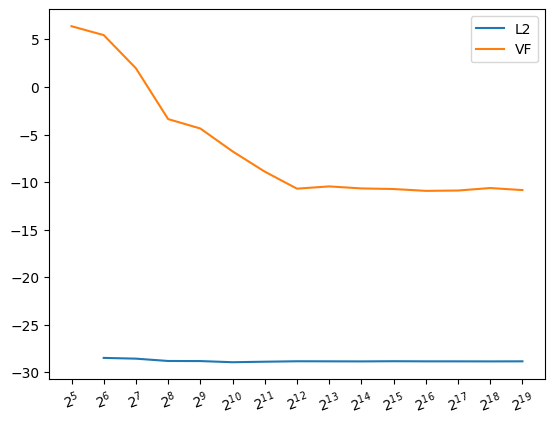

In [477]:
num_labels = [2**i for i in range(5,20)]

plt.plot(np.arange(len(num_labels)), np.log10(mse_L2s), label='L2')
plt.plot(np.arange(len(num_labels)), np.log10(mse_VFs), label='VF')
plt.xticks(np.arange(len(num_labels)), [f'$2^{{{i}}}$' for i in range(5,20)],
       rotation=20)
plt.legend()
plt.show()

In [54]:
mse_L2s

[0.0,
 3.294654368864226e-29,
 2.7409049491208487e-29,
 1.5607071634666682e-29,
 1.5283456755431043e-29,
 1.1538174339001832e-29,
 1.3082184144947232e-29,
 1.4585498745464562e-29,
 1.4347445332970524e-29,
 1.4089355494668344e-29,
 1.473331805325629e-29,
 1.4302384652677788e-29,
 1.4275495730015314e-29,
 1.4096462705274932e-29,
 1.4351321408331172e-29]

In [58]:
[0.001*2**i for i in range(0,11)]

[0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, 0.128, 0.256, 0.512, 1.024]

In [43]:
mse_L2s_noise = []
mse_VFs_noise = []
for noise_ratio in [0.001*2**i for i in range(0,11)]:
    # noise_ratio = 0.0
    num_points = 500
    num_basis = 50
    train_samples, test_samples = [], []
    task = "Lotka_Volterra"
    # task = "Lorenz"
    # task = "SIR"
    # task = "Fluid_Flow"
    # task = "Fluid_Flow"
    # task = "Repressilator3"
    # task = "Glycolytic_Oscillator"
    
    task_ode_num = 1
    num_env = 1    

    dt = 0.01 if num_points < 500 else 0.01 * 500 / num_points
    time_string = "20240216_024249_980909" #get_now_string()
    args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                     sample_strategy='uniform', params_strategy='default', 
                     train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                     save_folder='data/', train_sample_strategy='uniform', 
                     use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=3, 
                     dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                     main_path='./',data_dir='data/', dt=dt)
    args.train_test_total_list = [num_points]
    
    ode = ODE_DICT.get(args.task)(args)
    ode.n = int(ode.params_config["t_max"] / dt)
    ode.t_series = np.linspace(ode.params_config["t_min"],
        ode.params_config["t_max"] - dt, ode.n)
    ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.build()
    
    save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)
    
    info = None
    with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
        info = json.load(f)
    
    for env in range(num_env):
        trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
        tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
        trs = trs.sort_values(by='t', ascending=True)
        tes = tes.sort_values(by='t', ascending=True)
        train_samples.append(trs)
        test_samples.append(tes)
    
    eq = "C*x - C*x*y"
    data_list = train_samples
    _,_,mse_L2, mse_VF = score_with_est(eq, 11, data_list, reward_rescale=False,
                   eta=0.99,
                   error_tolerance=0.99,
                   combine_rewards=combine_rewards_original,
                   loss_func="L2",num_basis=num_basis,)
    mse_L2s_noise.extend(mse_L2) 
    mse_VFs_noise.extend(mse_VF)

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.001
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.001, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.68it/s]


TypeError: unsupported operand type(s) for +: 'float' and 'tuple'

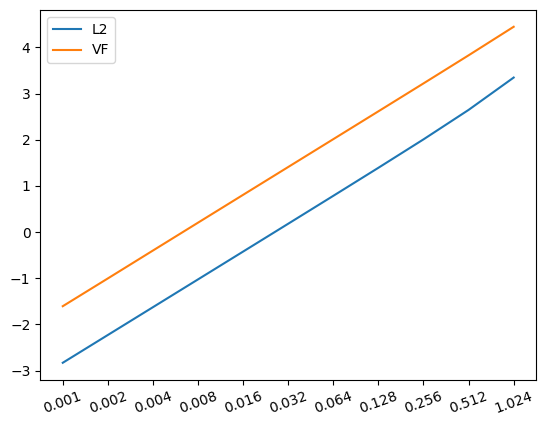

In [481]:
noise_levels = [0.001*2**i for i in range(0,11)]

plt.plot(np.arange(len(noise_levels)), np.log10(mse_L2s_noise), label='L2')
plt.plot(np.arange(len(noise_levels)), np.log10(mse_VFs_noise), label='VF')
plt.xticks(np.arange(len(noise_levels)), [f'{n}' for n in noise_levels],
       rotation=20)
plt.legend()
plt.show()

In [536]:
mse_L2s_basis = []
mse_VFs_basis = []

# num_basis_list = [3,4,5,6,7]


num_basis_list = []
num_basis_list += [i for i in range(2,101,2)]

# eq_list = ["1.0*x - 0.3*x*y", 
#            "0.997*x-0.299*x*y-0.02*y",
#            "(C/(x*y))",
#            "C*x*x*y + y",
#            "C*y*y*x + C*x",
#            '(x+(y-(x/y)))']
# eq_list = [
#     "1.0*x - 0.3*x*y", 
#     "0.997*x-0.299*x*y-0.02*y",
#     # '6.4-5*x**2*y + 0.00046*x*y**2 - 0.31*x*y + 1.0*x',
#     # "1.0*x-0.31*x*y-0.00046*y**2*x+6.4-5*x**2*y", 30663319669585565
#     '6.4e-5*x**2*y + 4.56e-4*x*y**2 - 0.3066*x*y + 1.0*x',
#     "0.9*x-0.3*x*y",
#     # "C*x**2-C*x*y",
#     # "C*x**2-C*y",
#     # "C*y**2/x-C*y",
#     # '-0.003*x**2*y + y',
#     "-0.03*x*y**2 + 0.6*x",
#     # "C*y*y*x + C*x",
#     '(x+(y-(x/y)))'
# ]
eq_list = [
    '(x+(y-(x/y)))',
    '-0.03*x*y**2 + 0.6*x',
    '0.9*x-0.3*x*y',
    '6.4e-5*x**2*y + 4.56e-4*x*y**2 - 0.3066*x*y + 1.0*x',
    '0.997*x-0.299*x*y-0.02*y',
    '1.0*x - 0.3*x*y',
]
eqs_test = {}
for eq in eq_list:
    eqs_test[eq] =  {"VF":[], "L2":[]}
    for num_basis in num_basis_list:
        noise_ratio = 0.00
        num_points = 500
        # num_basis = 50
        train_samples, test_samples = [], []
        task = "Lotka_Volterra"
        # task = "Lorenz"
        # task = "SIR"
        # task = "Fluid_Flow"
        # task = "Fluid_Flow"
        # task = "Repressilator3"
        # task = "Glycolytic_Oscillator"
        
        task_ode_num = 1
        num_env = 1    
    
        # dt = 0.01 if num_points < 500 else 0.01 * 500 / num_points
        dt = 0.01
        # dt = 0.01
        time_string = "20240216_024249_980909" #get_now_string()
        args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                         sample_strategy='uniform', params_strategy='default', 
                         train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                         save_folder='data/', train_sample_strategy='uniform', 
                         use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=3, 
                         dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                         main_path='./',data_dir='data/', dt=dt)
        args.train_test_total_list = [num_points]
        
        ode = ODE_DICT.get(args.task)(args)
        ode.n = int(ode.params_config["t_max"] / dt)
        ode.t_series = np.linspace(ode.params_config["t_min"],
            ode.params_config["t_max"] - dt, ode.n)
        ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
        ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
        ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
        ode.build()
        
        save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)
        
        info = None
        with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
            info = json.load(f)
        
        for env in range(num_env):
            trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
            tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
            trs = trs.sort_values(by='t', ascending=True)
            tes = tes.sort_values(by='t', ascending=True)
            train_samples.append(trs)
            test_samples.append(tes)
        
        # eq = "1.0*x - 0.3*x*y"
        # eq = "C*x-C*x*y"
        # eq = "0.997*x-0.299*x*y-0.02*y"
        # eq = "C/x*y"
        data_list = train_samples
        _,found_eq,mse_L2, mse_VF = score_with_est(eq, 11, data_list, reward_rescale=False,
                       eta=0.99,
                       error_tolerance=0.99,
                       combine_rewards=combine_rewards_original,
                       loss_func="L2",num_basis=num_basis,)
        # mse_L2s_basis.extend(mse_L2) 
        # mse_VFs_basis.extend(mse_VF)
        eqs_test[eq]["L2"].extend(mse_L2) 
        eqs_test[eq]["VF"].extend(mse_VF) 
        eqs_test[eq]["eq"] = found_eq

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.29it/s]


ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.15it/s]


ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


...

100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.36it/s]


ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.32it/s]


ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.30it/s]


In [548]:
# # plt.plot(np.arange(len(num_basis_list)), (mse_L2s_basis), label='L2')
# # plt.plot(np.arange(len(num_basis_list)), (mse_VFs_basis), label='VF')
# from scipy.stats import linregress


# plt.figure(figsize=(10, 6))
# num_basis_list_new = num_basis_list[2:]
# for i, eq in enumerate(eq_list):
#     # if i < 2:
#     #     continue
#     diff = np.abs(np.array(eqs_test[eq]["VF"][2:]) - np.array(eqs_test[eq]["L2"][2:]))
#     slope, _, _, _, _ = linregress(np.log(np.array(num_basis_list_new)), np.log(diff))
#     plt.plot(np.log(np.array(num_basis_list_new)), np.log(diff), 
#              label=f'slope={slope:<6.02f}{eq}', marker='.')
    
#     # plt.plot(np.log(np.array(num_basis_list_new)), -np.log(np.array(num_basis_list_new))+np.log(diff[0]))
# # plt.plot(np.arange(len(num_basis_list)), np.zeros(len(num_basis_list)), 'k-')
# plt.xticks(np.log(np.array(num_basis_list_new)), [f'{n}' for n in num_basis_list_new],
#        rotation=90)
# # plt.xticks(np.log(np.array(num_basis_list_new)), ['6', '8', '10', '12', '14', '16', '', '20', '', '24', '', '28', '', '32', '', '36', '', '40', '', '', '', '', '50', '', '', '', '', '60', '', '', '', '', '70', '', '', '', '', '80', '', '', '', '', '90', '', '', '', '','100']
# ,
#        # rotation=45)
# plt.xlabel("# basis")
# plt.ylabel("Estimated difference")
# # plt.title(f"Equation: {eq[0]}")
# plt.grid(alpha=0.3)
# plt.legend()
# plt.show()

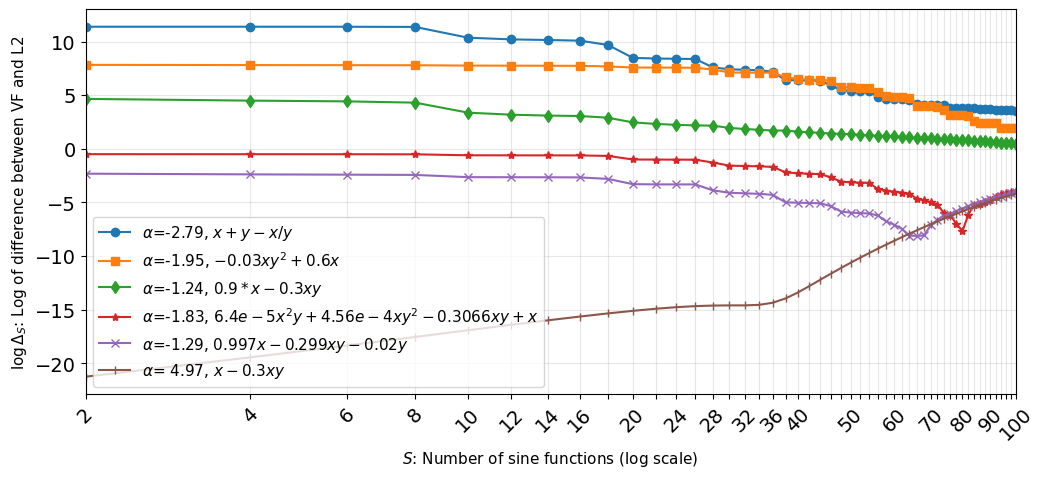

In [609]:
from scipy.stats import linregress

# plt.plot(np.arange(len(num_basis_list)), (mse_L2s_basis), label='L2')
# plt.plot(np.arange(len(num_basis_list)), (mse_VFs_basis), label='VF')
first_index = 0
plt.figure(figsize=(12, 5))
num_basis_list_new = num_basis_list[0:]
eq_list_formatted = [
    '$x+y-x/y$',
    '$-0.03xy^2 + 0.6x$',
    '$0.9*x-0.3xy$',
    '$6.4e-5x^2y + 4.56e-4xy^2 - 0.3066xy + x$',
    '$0.997x-0.299xy-0.02y$',
    '$x - 0.3xy$',
]
markers = ['o', 's', 'd', '*', 'x', '|', '_']

for i, eq in enumerate(eq_list):
    # if i < 2:
    #     continue
    diff = np.abs(np.array(eqs_test[eq]["VF"][first_index:]) - np.array(eqs_test[eq]["L2"][first_index:]))
    # plt.plot(np.log(np.array(num_basis_list_new)), np.log(diff), 
    #          label=f'{eq}', marker='.')
    slope, _, _, _, _ = linregress(np.log(np.array(num_basis_list_new)), np.log(diff))
    plt.plot(np.log(np.array(num_basis_list_new)), np.log(diff), 
             label=f'$\\alpha$={slope:>5.02f}, {eq_list_formatted[i]}', marker=markers[i])
    # plt.plot(np.log(np.array(num_basis_list_new)), -np.log(np.array(num_basis_list_new))+1+np.log(diff[0]))
# plt.plot(np.arange(len(num_basis_list)), np.zeros(len(num_basis_list)), 'k-')
# plt.xticks(np.log(np.array(num_basis_list_new)), [f'{n}' for n in num_basis_list_new],
       # rotation=90)
plt.xticks(np.log(np.array(num_basis_list_new)), ['2', '4', '6', '8', '10', '12', '14', '16', '', '20', '', '24', '', '28', '', '32', '', '36', '', '40', '', '', '', '', '50', '', '', '', '', '60', '', '', '', '', '70', '', '', '', '', '80', '', '', '', '', '90', '', '', '', '','100']
,
       rotation=45, fontsize=14,)
plt.yticks(fontsize=14)
# plt.xlabel("$S$: Number of sine functions")
# plt.ylabel("$\log \Delta_S$: Log of difference between VF and L2")
plt.xlabel("$S$: Number of sine functions (log scale)", fontsize=11)
plt.ylabel("$\log \Delta_S$: Log of difference between VF and L2", fontsize=11)
# plt.title(f"Equation: {eq[0]}")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
# plt.gca().set_axis_off()
# plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0, 
#             hspace = 0, wspace = 0)
plt.margins(0,0.05)
# plt.savefig("vf_conv.pdf",bbox_inches='tight')
plt.show()

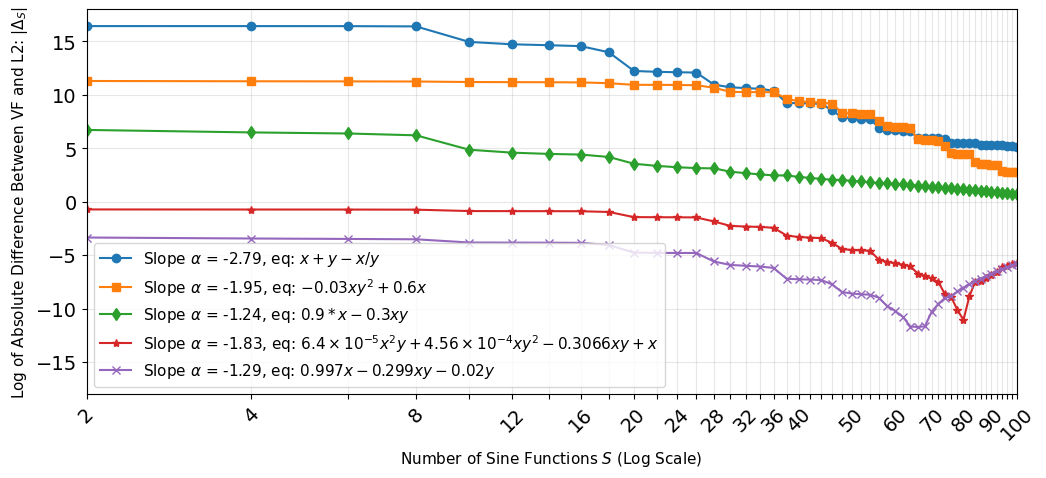

In [646]:
from scipy.stats import linregress

# plt.plot(np.arange(len(num_basis_list)), (mse_L2s_basis), label='L2')
# plt.plot(np.arange(len(num_basis_list)), (mse_VFs_basis), label='VF')
first_index = 0
end_index = len(num_basis_list)#19
plt.figure(figsize=(12, 5))
num_basis_list_new = num_basis_list[first_index:end_index]
eq_list_formatted = [
    '$x+y-x/y$',
    '$-0.03xy^2 + 0.6x$',
    '$0.9*x-0.3xy$',
    '$6.4\\times 10^{-5} x^2y + 4.56\\times 10^{-4}xy^2 - 0.3066xy + x$',
    '$0.997x-0.299xy-0.02y$',
    '$x - 0.3xy$',
]
markers = ['o', 's', 'd', '*', 'x', '|', '_']

for i, eq in enumerate(eq_list):
    if i == len(eq_list)-1:
        continue
    # print(np.array(eqs_test[eq]["L2"][first_index:end_index])-np.array(eqs_test[eq]["VF"][first_index:end_index]))
    diff = np.abs(np.array(eqs_test[eq]["VF"][first_index:end_index]) - np.array(eqs_test[eq]["L2"][first_index:end_index]))
    # plt.plot(np.log(np.array(num_basis_list_new)), np.log(diff), 
    #          label=f'{eq}', marker='.')
    slope, _, _, _, _ = linregress(np.log2(np.array(num_basis_list_new)), np.log2(diff))
    plt.plot(np.log2(np.array(num_basis_list_new)), np.log2(diff), 
             label=f'Slope $\\alpha$ = {slope:>5.02f}, eq: {eq_list_formatted[i]}', marker=markers[i])
    # plt.plot(np.log(np.array(num_basis_list_new)), -np.log(np.array(num_basis_list_new))+1+np.log(diff[0]))
# plt.plot(np.arange(len(num_basis_list)), np.zeros(len(num_basis_list)), 'k-')
# plt.xticks(np.log(np.array(num_basis_list_new)), [f'{n}' for n in num_basis_list_new],
       # rotation=90)
plt.xticks(np.log2(np.array(num_basis_list_new)), ['2', '4', '', '8', '', '12', '', '16', '', '20', '', '24', '', '28', '', '32', '', '36', '', '40', '', '', '', '', '50', '', '', '', '', '60', '', '', '', '', '70', '', '', '', '', '80', '', '', '', '', '90', '', '', '', '','100']
,
       rotation=45, fontsize=14,)
plt.yticks(fontsize=14)
# plt.xlabel("$S$: Number of sine functions")
# plt.ylabel("$\log \Delta_S$: Log of difference between VF and L2")
plt.xlabel("Number of Sine Functions $S$ (Log Scale)", fontsize=11)
plt.ylabel("Log of Absolute Difference Between VF and L2: $|\Delta_S|$", fontsize=11)
# plt.title(f"Equation: {eq[0]}")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
# plt.gca().set_axis_off()
# plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0, 
#             hspace = 0, wspace = 0)
plt.ylim([-18,18])
plt.margins(0,0.05)
plt.savefig("vf_conv.pdf",bbox_inches='tight')
plt.show()

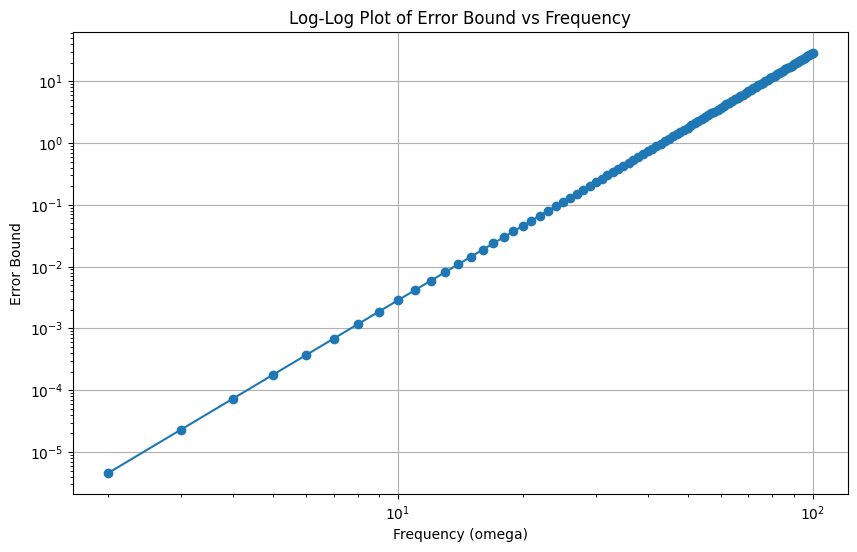

In [610]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
a = 0
b = 20
n = 500
h = (b - a) / n
constant = (20 * h**4) / 180

# Frequency range
omega = np.arange(2, 101)
errors = constant * omega**4

# Log-Log Plot
plt.figure(figsize=(10, 6))
plt.loglog(omega, errors, marker='o', linestyle='-')
plt.title('Log-Log Plot of Error Bound vs Frequency')
plt.xlabel('Frequency (omega)')
plt.ylabel('Error Bound')
plt.grid(True)
plt.show()

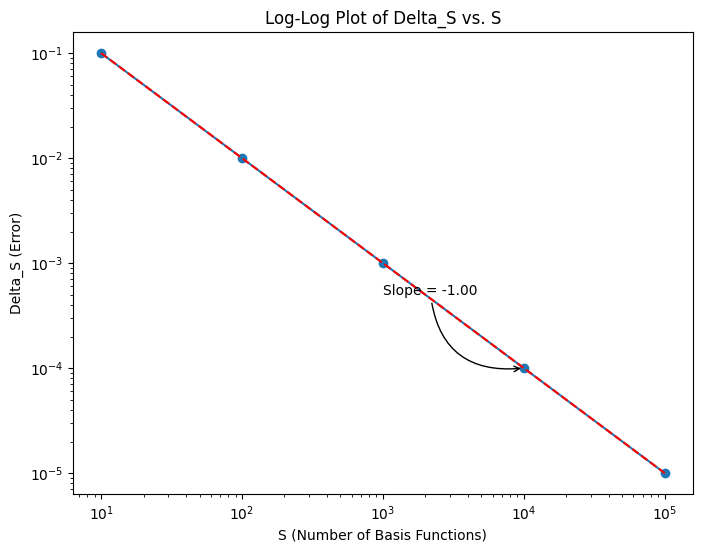

In [458]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Sample data
S = np.array([10, 100, 1000, 10000, 100000])  # Number of basis functions
Delta_S = np.array([0.1, 0.01, 0.001, 0.0001, 0.00001])  # Errors

# Calculating the logarithms of S and Delta_S
log_S = np.log(S)
log_Delta_S = np.log(Delta_S)

# Fitting a linear regression to the log-log data
slope, intercept, r_value, p_value, std_err = linregress(log_S, log_Delta_S)

# Create a log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(S, Delta_S, 'o-', label='Experimental Data')

# Plot the fit line
fit_line = np.exp(intercept) * S**slope  # Convert back to the original scale
plt.loglog(S, fit_line, 'r--', label='Fit Line')

# Annotations
plt.title('Log-Log Plot of Delta_S vs. S')
plt.xlabel('S (Number of Basis Functions)')
plt.ylabel('Delta_S (Error)')

# Annotate the slope on the graph
plt.annotate(f'Slope = {slope:.2f}', xy=(S[-2], fit_line[-2]), xytext=(S[-3], fit_line[-2]*5),
             textcoords='data', arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.5"))

# Show the plot
plt.show()

In [451]:
print([f'{n}' for n in num_basis_list_new])

['6', '8', '10', '12', '14', '16', '18', '20', '22', '24', '26', '28', '30', '32', '34', '36', '38', '40', '42', '44', '46', '48', '50', '52', '54', '56', '58', '60', '62', '64', '66', '68', '70', '72', '74', '76', '78', '80', '82', '84', '86', '88', '90', '92', '94', '96', '98']


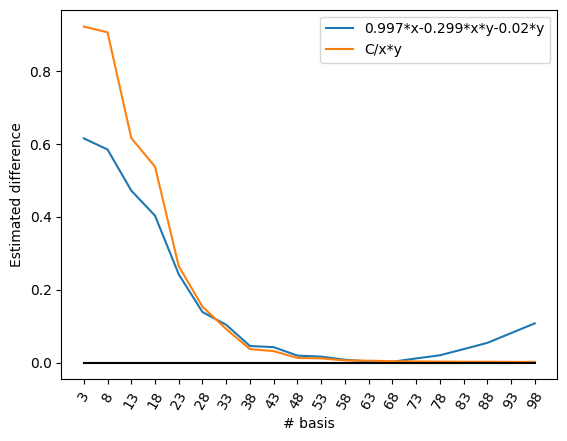

In [424]:
for i, eq in enumerate(eq_list):
    if i < 1:
        continue
    plt.plot(np.arange(len(num_basis_list)), np.abs(np.array(eqs_test[eq]["VF"]) - np.array(eqs_test[eq]["L2"])) / np.array(eqs_test[eq]["L2"]), 
             label=f'{eq}')
plt.plot(np.arange(len(num_basis_list)), np.zeros(len(num_basis_list)), 'k-')
plt.xticks(np.arange(len(num_basis_list)), [f'{n}' for n in num_basis_list],
       rotation=60)
plt.xlabel("# basis")
plt.ylabel("Estimated difference")
# plt.title(f"Equation: {eq[0]}")
plt.legend()
plt.show()

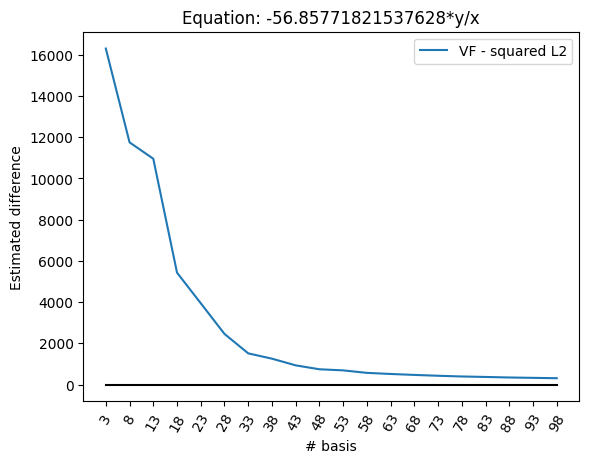

In [359]:
plt.plot(np.arange(len(num_basis_list)), np.zeros(len(num_basis_list)), 'k-')
plt.plot(np.arange(len(num_basis_list)), (np.array(mse_L2s_basis) - np.array(mse_VFs_basis)), 
         label='VF - squared L2')
# plt.plot(np.arange(len(num_basis_list)), np.array(num_basis_list) * , 
#          label='1/S')
# plt.plot(np.arange(len(num_basis_list)), np.array(num_basis_list) * (np.array(mse_L2s_basis) - np.array(mse_VFs_basis)), 
#          label='S(VF - squared L2)')
plt.xticks(np.arange(len(num_basis_list)), [f'{n}' for n in num_basis_list],
       rotation=60)
plt.xlabel("# basis")
plt.ylabel("Estimated difference")
plt.title(f"Equation: {eq[0]}")
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

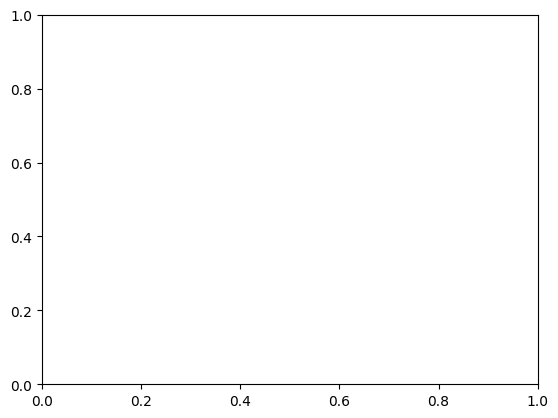

In [392]:
# plt.plot(np.arange(len(num_basis_list)), np.zeros(len(num_basis_list)), 'k-')
plt.plot(1/np.array(num_basis_list), (np.array(mse_L2s_basis) - np.array(mse_VFs_basis)) , 
         label='VF - squared L2',)
# plt.xticks(1/np.array(num_basis_list), [f'{n}' for n in num_basis_list],
#        rotation=60)
plt.xlabel("1/S")
plt.ylabel("Estimated difference")
plt.title(f"Equation: {eq[0]}")
plt.gca().invert_xaxis()
plt.grid()
plt.legend()
plt.show()

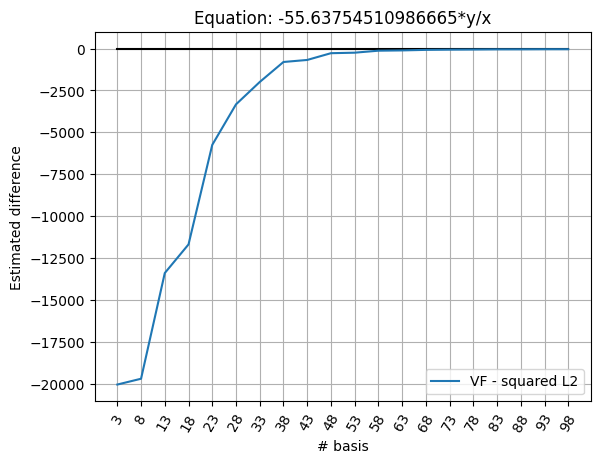

In [384]:
plt.plot(np.arange(len(num_basis_list)), np.zeros(len(num_basis_list)), 'k-')
plt.plot(np.arange(len(num_basis_list)), np.array(mse_VFs_basis) - np.array(mse_L2s_basis), 
         label='VF - squared L2')
plt.xticks(np.arange(len(num_basis_list)), [f'{n}' for n in num_basis_list],
       rotation=60)
plt.xlabel("# basis")
plt.ylabel("Estimated difference")
plt.title(f"Equation: {eq[0]}")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Demonstrate VF is worse at low error
# Same/different functions (modify scoring) 
# Really want to do: 
# Num points & num basis & noise
# 

In [ ]:
# options={'return_all':True}

In [446]:
with open("../Invariant_Physics/notebooks/test_eqs.pkl", 'rb') as f:
    eqs = pickle.load(f)
eqs[:10]

['(x-(((x*((y*C)*C))-((((y*((y/y)-(x+((x*y)*C))))*C)*C)*(((x*y)*C)*C)))-((((x/y)+(x+y))+((x/x)*y))*x)))',
 '((y*C)+((x-x)+y))',
 '((x-((y*C)*C))*C)',
 '(x-((((x*C)+x)-y)-(y*x)))',
 '(x+((x/y)/x))',
 '(x-((x+x)-(x-((x+(y*C))*C))))',
 '(((y*(y+y))*C)*C)',
 '((y*C)-((((y/y)*C)*x)/x))',
 '((y/((y*C)-x))/(x+y))',
 '(x+(y-(x/y)))']

In [65]:
from math import sqrt, pi
from typing import Callable

import numpy as np
from numpy import ndarray, newaxis

from scipy.integrate import trapz, simps
from invariant_physics.loss.integrate import trapezoid#, simpson

import torch
from torch import Tensor
def trapezoid(x: Tensor, tspan: Tensor = None, dt: float = None, dim: int = 0):
    x = torch.tensor(x)
    xT = x.transpose(0, dim)
    if dt is not None:
        assert tspan is None
        term1 = xT[1:-1].sum(dim = 0, keepdim = True)
        integ_x: Tensor = dt * (xT[0] + 2 * term1 + xT[-1]) / 2
    elif tspan is not None:
        tspan = torch.tensor(tspan)
        assert tspan.dim() == 1
        assert dt is None
        factor1 = ((xT[:,:-1] + xT[:,1:]) / 2).reshape(-1, xT.shape[0], 1)
        factor2 = (tspan[1:] - tspan[:-1]).reshape((-1,) + (1,) * (factor1.dim() - 1))
#         torch.Size([49, 400, 1]) torch.Size([399, 1, 1])
#         print(factor1.shape, factor2.shape)
        integ_x: Tensor = (factor2 * factor1).sum(dim = 0, keepdim = True)
    return integ_x.transpose(0, dim).squeeze(dim)

def simpson(x: Tensor, dt: float = None, dim: int = -1):
    x = torch.tensor(x)
#     print(x.shape)
    xT = torch.squeeze(x).transpose(0, dim)
    x_even = xT if len(xT) % 2 else xT[:-3]
    term1: Tensor = x_even[1:-1:2].sum(dim = 0, keepdim = True)
    term2: Tensor = x_even[2:-1:2].sum(dim = 0, keepdim = True)
    integ_x: Tensor = 2 * dt / 6 * (x_even[0] + 4 * term1 + 2 * term2 + x_even[-1])
    if not len(xT) % 2:
        term3 = xT[-4] + 3*xT[-3] + 3*xT[-2] + xT[-1]
        integ_x = integ_x + 3 * dt * term3 / 8
    return integ_x.transpose(0, dim).squeeze(dim)


class VF_Loss:
    '''
        Create a `VF_loss` object with specific settings. Now
        only `fourier` is supported.
        
        Args:
        - `func_num`: the number of sine functions you would like to use. 
            40~50 is recommend.
        - `func_type`: Now only `fourier` is supported.
        - `integ_method`: numerical integration method. It should be chosen from `simps` 
            and `trapz`.
            Recommendation: `simps` > `trapz`
        - `reduction`: sum or mean.
        '''
    def __init__(
        self, 
        func_num: int,  
        func_type: str = 'fourier',
        integ_method: str = 'simps',
        reduction: str = 'mean', 
    ) -> None:
        super().__init__()
        self.func_num, self.func_type = func_num, func_type
        self.integ_method = integ_method
        self.reduction = reduction
        
    def fourier_basis(self, tspan: ndarray):
        '''
        Generate sine functions.
        
        Mathematical Expressions: 
            ``g_s(t) = sqrt(2/T) sin (s*pi*t / T)``
            
        Attention: `tspan` must be `0, dt, 2dt, ..., T`.
        
        Return shape: `(func_num, len(tspan))`
        '''
        T = tspan[-1]
        s = np.arange(1, self.func_num + 1, 1.0).reshape((-1, 1))
        funcs_input = pi * s @ tspan.reshape((1, -1)) / T
        # print(funcs_input.shape)
        # print(tspan)
        gs = sqrt(2 / T) * np.sin(funcs_input)
        dgs = pi * s / T * sqrt(2 / T) * np.cos(funcs_input)
        # plt.plot(tspan.reshape(-1, 1), gs.T)
        # plt.show()
        # plt.plot(tspan.reshape(-1, 1), dgs.T)
        # plt.show()
        return gs, dgs # (func_num, len(tspan))
        
    def __call__(self, f: ndarray, X: ndarray, tspan: ndarray, f_true=None) -> ndarray:
        '''
        Shape of inputs:
        - `X.shape`: `(len(tspan), traj_num)`
        - `f.shape`: `(len(tspan), traj_num)`
        - `tspan`: `0, dt, 2dt, ..., T`
        '''
        return self.integ_regular(f, X, tspan, f_true=f_true)
        # tspan.shape: (len(tspan)[, traj_num])
        # if tspan.axis() == 1: return self.integ_regular(ode_func, X, tspan)
        # elif tspan.axis() == 2: return self.integ_irregular(ode_func, X, tspan)
        
    def integ_regular(self, f: ndarray, X: ndarray, tspan: ndarray, f_true=None):
        '''
        Shape of inputs:
        - `X.shape`: `(len(tspan), traj_num)`
        - `f.shape`: `(len(tspan), traj_num)`
        - `tspan`: `0, dt, 2dt, ..., T`
        '''
        if self.func_type == 'fourier': g, dg = self.fourier_basis(tspan)
        else: raise NotImplementedError 
        # (func_num, len(tspan), traj_num)
        integrand = f * g[..., newaxis] + X * dg[..., newaxis]

        # print(f.shape, X.shape)
        if self.integ_method == 'simps':
            # print((f * g[..., newaxis]).shape, (X * dg[..., newaxis]).shape)
            first = f * g[..., newaxis]
            second = X * dg[..., newaxis]
            # print(first.shape, second.shape)
            # f = lambda x: x**2 + 2*x
            # f_prime = lambda x: 2*x + 2
            # first = f_prime(tspan).reshape(-1,1) * g[..., newaxis]
            # second = f(tspan).reshape(-1,1) * dg[..., newaxis]
            # integrand = first + second
            # print(first.shape, second.shape)
            first = simpson(first, float(tspan[1] - tspan[0]), dim = 1) 
            second = simpson(second, float(tspan[1] - tspan[0]), dim = 1) 
            # if f_true is not None:
            #     second_true = -f_true * g[..., newaxis]
            #     second = simpson(second_true, float(tspan[1] - tspan[0]), dim = 0) 
                # plt.plot(tspan.reshape(-1,1), second.squeeze().T[:, :3])
                # plt.show()
                # plt.plot(tspan.reshape(-1,1), second_true.squeeze().T[:, :3])
                # plt.show()
                # plt.plot(tspan.reshape(-1,1), (X*g[..., newaxis]).squeeze().T[0, :3] + (X*g[..., newaxis]).squeeze().T[-1, :3] )
                # plt.show()
                # print(X[0],X[-1])
                # plt.plot(tspan.reshape(-1,1), second.squeeze().T[:, :3] + (X*g[..., newaxis])[0, :3] + (X*g[..., newaxis])[-1, :3] )
                # plt.show()
            # print(first.shape)
            
            # print(first)
            # print()
            # print(second)
            loss_raw: ndarray = (simpson(integrand, float(tspan[1] - tspan[0]), dim = 1) **2).sum(axis = 0).numpy()
            # loss_raw: ndarray = ((first+second)**2).sum(axis = 0).numpy()
            # raise
            # import pdb;pdb.set_trace()
            # print(first.squeeze().shape)
            first = ((first)**2).sum(axis = 0).numpy()
            second = ((second)**2).sum(axis = 0).numpy()
            
        elif self.integ_method == 'trapz':
            loss_raw: ndarray = (trapezoid(integrand, tspan, dim = 0)**2).sum(axis = 0).numpy()
        else: raise NotImplementedError 
            
#         if self.integ_method == 'simps':
#             loss_raw: ndarray = (simps(integrand, tspan, axis = 1)**2).sum(axis = 0)
#         elif self.integ_method == 'trapz':
#             loss_raw: ndarray = (trapz(integrand, tspan, axis = 1)**2).sum(axis = 0)
#         else: raise NotImplementedError 
            
        if self.reduction == 'sum': return loss_raw.sum()
        elif self.reduction == 'mean': return loss_raw.mean(), first.mean(), second.mean()
        else: raise ValueError('Reduction mode is not set correctly!')
       

def score_with_est(ode, eq, tree_size, data_list, eta,
                   combine_rewards=combine_rewards_original,
                   task_ode_num=1, t_limit = 1.0,
                   reward_rescale=False, error_tolerance=0.5,
                   combine_operator="min", loss_func="L2", data_t_series_list=None,
                   num_basis=50,):
    """
    Calculate reward score for a complete parse tree 
    If placeholder C is in the equation, also excute estimation for C 
    Reward = 1 / (1 + MSE) * Penalty ** num_term 

    Parameters
    ----------
    eq : Str object.
        the discovered equation (with placeholders for coefficients). 
    tree_size : Int object.
        number of production rules in the complete parse tree. 
    data : 2-d numpy array.
        measurement data, including independent and dependent variables (last row). 
    t_limit : Float object.
        time limit (seconds) for single evaluation, default 1 second. 
        
    Returns
    -------
    score: Float
        discovered equations. 
    eq: Str
        discovered equations with estimated numerical values. 
    """
    # For VF
    assert loss_func in ["L2", "VF"]
    # if loss_func == "VF":
    #     assert all(param is not None for param in [data_t_series])
    vf_criterion: VF_Loss = VF_Loss(func_num=num_basis, integ_method='simps')
    # print(f"input data_list[0]: {data_list[0][:20]}")

    r_diff_list, r_parsimony_list, eqs = [], [], []
    mse_L2s, mse_VFs = [], []
    mse_VF_firsts, mse_VF_seconds, mse_L2s_true = [], [], []
    if isinstance(eq, list):
        initial_eqs = eq
    else:
        initial_eqs = [eq] * len(data_list)
        
    for env, data in enumerate(data_list):
        # print(f"[normal] one data shape: {data.shape} ")
        eq = initial_eqs[env]

        ## define independent variables and dependent variable
        variables = list(data.columns)
        first_d_idx = variables.index('d'+variables[1])
        for variable in variables[:first_d_idx]:
            globals()[variable] = data[variable].to_numpy()
        target_variable = variables[first_d_idx + task_ode_num - 1]
        origin_variable = variables[1 + task_ode_num - 1]
        globals()['f_true'] = data[target_variable].to_numpy()
        globals()['y_true'] = data[origin_variable].to_numpy()
        data_t_series = data['t'].to_numpy()
        # print(f"@@@@@ data[target_variable].to_numpy()={data[target_variable].to_numpy()[:20]}")

        ## count number of numerical values in eq
        c_count = eq.count('C')
        # start_time = time.time()
        with time_limit(t_limit, 'sleep'):
            try: 
                if c_count == 0:       ## no numerical values
                    f_pred = eval(eq)
                elif c_count >= 10:    ## discourage over complicated numerical estimations
                    return None,None,None,None,None,None,None
                else:                  ## with numerical values: coefficient estimationwith Powell method

                    # eq = prune_poly_c(eq)
                    c_lst = ['c'+str(i) for i in range(c_count)]
                    for c in c_lst: 
                        eq = eq.replace('C', c, 1)

                    def eq_test(c):
                        for i in range(len(c)): globals()['c'+str(i)] = c[i]
                        if loss_func == "VF":
                            xx = np.stack([y_true], axis=1)
                            ff = np.stack([eval(eq)], axis=1)
                            eq_diff,_,_ = vf_criterion(ff, xx, data_t_series)
                        else:
                            eq_diff = np.linalg.norm(eval(eq) - f_true, 2)
                        return eq_diff

                    x0 = [1.0] * len(c_lst)
                    # all_x_i = [x0[0]]
                    # all_y_i = [x0[1]]
                    # all_f_i = [eq_test(x0)]
                    # def store(X):
                    #     x, y = X
                    #     all_x_i.append(x)
                    #     all_y_i.append(y)
                    #     all_f_i.append(eq_test(X))
                    # optimize.minimize(f, x0, method="CG", options={"gtol": 1e-12})
                    res = minimize(eq_test, x0, method='Powell', tol=1e-6, options={'return_all':True})
                    # res = minimize(eq_test, x0, method='Powell', tol=1e-6, callback=store, options={'return_all':True})                    # print(res)
                    # import pdb;pdb.set_trace()
                    # print(all_x_i, all_y_i, all_f_i)
                    c_lst = res.x.tolist() 
                    
                    # env_clst = {
                    #     0: [1.0, 0.3],
                    #     1: [1.2, 0.39],
                    #     2: [1.3, 0.42],
                    #     3: [1.1, 0.51],
                    #     4: [0.9, 0.39]
                    # }
                    # c_lst = env_clst[env]
                    eq_est = eq
                    for i in range(len(c_lst)):
                        eq_est = eq_est.replace('c'+str(i), str(c_lst[i]), 1)
                    eq = eq_est.replace('+-', '-')
                    f_pred = eval(eq)
                    # print(f"[normal] output_v20240301 f_pred shape: {f_pred.shape} value: {f_pred[:10]}")
            except: 
                # raise
                return None,None,None,None,None,None,None

        for j in range(1,first_d_idx):
            globals()[variables[j]+'_true_actual'] = ode.y[env][ode.train_indices_list[env]][:, j-1]
        for variable in variables[:first_d_idx]:
            eq_true_raw = "x - 0.3*x*y"
            # eq_true_raw = '10.0*y-10.0*x'
            eq_true = eq_true_raw.replace(variable, variable+'_true_actual')
            
        f_true_correct = eval(eq_true)
        ff_true = np.stack([f_true_correct], axis=1)
        
        xx = np.stack([y_true], axis=1)
        ff = np.stack([f_pred], axis=1)
        # dis, dis_first, dis_second = vf_criterion(ff, xx, data_t_series)
        dis, dis_first, dis_second = vf_criterion(ff, xx, data_t_series, f_true=ff_true)
        r_diff = float(1 / (1.0 + dis))

        # f_pred is done in approx x,y
        diff_true = f_pred - f_true_correct
        diff = f_pred - f_true
        if reward_rescale:
            eps = 1e-6
            diff /= data[variables[task_ode_num]] + eps
        r_diff = float(1 / (1.0 + np.sqrt(np.linalg.norm(diff, 2) ** 2 / f_true.shape[0])))

        # print(diff)
        # print(f_true_correct)
        mse_L2s.append(np.linalg.norm(diff, 2) ** 2 / f_true.shape[0])
        mse_VFs.append(dis)
        mse_VF_firsts.append(dis_first)
        mse_VF_seconds.append(dis_second)
        mse_L2s_true.append(np.linalg.norm(diff_true, 2) ** 2 / f_true.shape[0])

        # plt.plot(f_true-f_true_correct) # Numerical differentiation errors
        # plt.ylim([-1e-2, 5e-1])
        # plt.show()

        # plt.plot(f_pred-f_true_correct) # Numerical errors propagated
        # plt.ylim([-1e-2, 5e-1])
        # plt.show()
        
        r_parsimony = eta ** tree_size
        r_diff_list.append(r_diff)
        r_parsimony_list.append(r_parsimony)
        eqs.append(eq)   
#     print(r_diff_list, r_parsimony_list)
    try:
        return (
            combine_rewards(r_diff_list, r_parsimony_list,
                            error_tolerance=error_tolerance,
                            combine_operator=combine_operator,
                            num_samples=[len(data) for data in data_list]),
            simplify_eqs(eqs),
            mse_L2s, mse_VFs, mse_VF_firsts, mse_VF_seconds, mse_L2s_true
        )
    except:
        print(eqs)
        raise


noise_ratio = 0.0
num_points = 500
num_basis = 50
train_samples, test_samples = [], []
task = "Lotka_Volterra"
# task = "Lorenz"
# task = "SIR"
# task = "Fluid_Flow"
# task = "Fluid_Flow"
# task = "Repressilator3"
# task = "Glycolytic_Oscillator"

task_ode_num = 1
num_env = 1    

# dt = 0.01 if num_points < 600 else 0.01 * 500 / num_points
dt = 0.01
time_string = "20240216_024249_980909" #get_now_string()
args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                 sample_strategy='uniform', params_strategy='default', 
                 train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                 save_folder='data/', train_sample_strategy='uniform', 
                 use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=1, 
                 dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                 main_path='./',data_dir='data/', dt=dt)
args.train_test_total_list = [num_points]

ode = ODE_DICT.get(args.task)(args)
ode.n = int(ode.params_config["t_max"] / dt)
ode.t_series = np.linspace(ode.params_config["t_min"],
    ode.params_config["t_max"] - dt, ode.n)
ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
ode.build()

save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)

info = None
with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
    info = json.load(f)

for env in range(num_env):
    trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
    tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
    trs = trs.sort_values(by='t', ascending=True)
    tes = tes.sort_values(by='t', ascending=True)
    train_samples.append(trs)
    test_samples.append(tes)

old_ode = ode

# dt = 0.01 if num_points < 600 else 0.01 * 500 / num_points
dt = 0.0001 # for accurate simulated variables
time_string = "20240216_024249_980909" #get_now_string()
args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                 sample_strategy='uniform', params_strategy='default', 
                 train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                 save_folder='data/', train_sample_strategy='uniform', 
                 use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=1, 
                 dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                 main_path='./',data_dir='data/', dt=dt)
args.train_test_total_list = [num_points]

ode = ODE_DICT.get(args.task)(args)
ode.n = int(ode.params_config["t_max"] / dt)
ode.t_series = np.linspace(ode.params_config["t_min"],
    ode.params_config["t_max"] - dt, ode.n)
ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
ode.build()
ode.train_indices_list[0] = old_ode.train_indices_list[0]*100

import pickle

with open("../Invariant_Physics/notebooks/test_eqs.pkl", 'rb') as f:
    eqs = pickle.load(f)
eqs[:10]

mse_L2s_eqs = []
mse_VFs_eqs = []
mse_VF_firsts = []
mse_VF_seconds = []
mse_L2s_trues = []
print(ode.y[0][ode.train_indices_list[0]][[0,-1], 0])
for eq in eqs:
    # eq = "C*x + C*x*y"
    # eq = "C*x"
    data_list = train_samples
    _, found_eq, mse_L2, mse_VF, mse_VF_first, mse_VF_second, mse_L2s_true = score_with_est(ode, eq, 11, data_list, reward_rescale=False,
                   eta=0.99,
                   error_tolerance=0.99,
                   combine_rewards=combine_rewards_original,
                   loss_func="L2",num_basis=num_basis,t_limit = 1e6)
    if mse_L2:
        mse_L2s_eqs.extend(mse_L2)
        mse_VFs_eqs.extend(mse_VF)
        mse_VF_firsts.extend(mse_VF_first)
        mse_VF_seconds.extend(mse_VF_second)
        mse_L2s_trues.extend(mse_L2s_true)
    break
mse_L2, mse_VF, mse_VF_first, mse_VF_second, mse_L2s_true, found_eq

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.07s/it]


ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.11it/s]


[10.         50.79177597]


([8096236.804084199],
 [125837695.53729483],
 [127813876.58751905],
 [20245.852838834013],
 [8096255.9382446],
 ['0.0063656312357144713*x**2*y**3 - 0.0088444658719607231*x**2*y**2 + x**2 + x**2/y + 0.0088444658719607231*x*y**2 - 30.558195090317298*x*y + x'])

In [8]:
# ode.t_series[old_ode.train_indices_list[0]*100]

In [9]:
# ([6.40949485492072e-30],
#  [4267839.661701334],
#  [21769.097231174248],
#  [4372701.614535172])

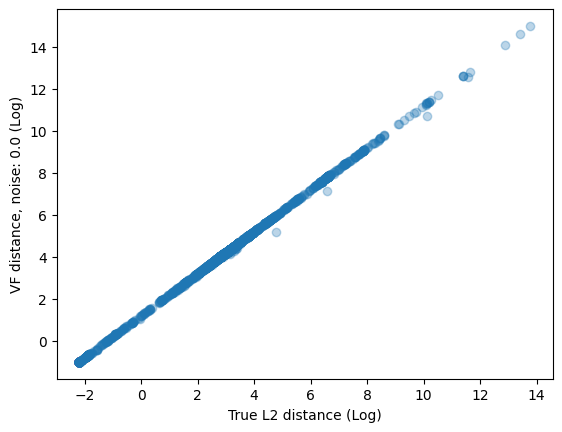

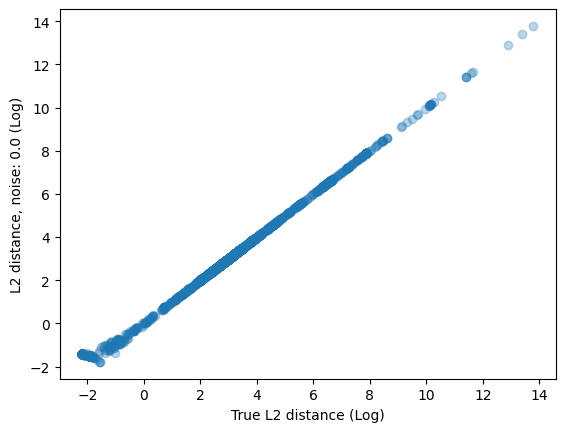

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


In [19]:
# mse_L2s_eqs = np.array(mse_L2s_eqs)[np.log10(mse_L2s_eqs) < 5]
mse_VFs_eqs = np.array(mse_VFs_eqs)
mse_VF_firsts = np.array(mse_VF_firsts)
mse_VF_seconds = np.array(mse_VF_seconds)
mse_L2s_eqs = np.array(mse_L2s_eqs)
mse_L2s_trues = np.array(mse_L2s_trues)

# 0, 3
n = 5
# plt.scatter(np.log10(mse_L2s_eqs), np.log10(mse_VF_firsts))
# plt.scatter(np.log10(mse_L2s_eqs), np.log10(mse_VF_seconds), alpha=0.3)
plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_VFs_eqs), alpha=0.3)
# plt.scatter((mse_L2s_eqs[np.log10(mse_L2s_eqs) < n]), (mse_VF_firsts[np.log10(mse_L2s_eqs) < n]))
# plt.scatter((mse_L2s_eqs[np.log10(mse_L2s_eqs) < n]), (mse_VF_seconds[np.log10(mse_L2s_eqs) < n]), alpha=0.3)
# plt.scatter((mse_L2s_trues[np.log10(mse_L2s_trues) < n]), (mse_VFs_eqs[np.log10(mse_L2s_trues) < n])/200, alpha=0.3)
plt.xlabel("True L2 distance (Log)")
plt.ylabel(f"VF distance, noise: {noise_ratio} (Log)")
# plt.xlim([-5.0,12.5])
# plt.xlim([0,100])
plt.show()

# -5, -3.7
plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_L2s_eqs), alpha=0.3)
# plt.scatter((mse_L2s_trues[np.log10(mse_L2s_trues) < n]), (mse_L2s_eqs[np.log10(mse_L2s_trues) < n]), alpha=0.3)
plt.xlabel("True L2 distance (Log)")
# plt.xlim([-5.0,12.5])
# plt.xlim([0, 0.5]
plt.ylabel(f"L2 distance, noise: {noise_ratio} (Log)")
plt.show()

In [44]:
result_dict = {}
import pickle

with open("../Invariant_Physics/notebooks/test_eqs.pkl", 'rb') as f:
    eqs = pickle.load(f)
eqs[:10]

for num_points in [10,20,50,100,200,500]:
    noise_ratio = 0.0
    num_basis = 50
    task = "Lotka_Volterra"
    # task = "Lorenz"
    # task = "SIR"
    # task = "Fluid_Flow"
    # task = "Fluid_Flow"
    # task = "Repressilator3"
    # task = "Glycolytic_Oscillator"
    # dt = 0.01 if num_points < 600 else 0.01 * 500 / num_points
    dt = 0.0001

    train_samples, test_samples = [], []
    task_ode_num = 1
    num_env = 1    
    
    time_string = "20240216_024249_980909" #get_now_string()
    args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                     sample_strategy='uniform', params_strategy='default', 
                     train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                     save_folder='data/', train_sample_strategy='uniform', 
                     use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=3, 
                     dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                     main_path='./',data_dir='data/', dt=dt)
    args.train_test_total_list = [num_points]
    
    ode = ODE_DICT.get(args.task)(args)
    ode.n = int(ode.params_config["t_max"] / dt)
    ode.t_series = np.linspace(ode.params_config["t_min"],
        ode.params_config["t_max"] - dt, ode.n)
    ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.build()
    
    save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)
    
    info = None
    with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
        info = json.load(f)
    
    for env in range(num_env):
        trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
        tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
        trs = trs.sort_values(by='t', ascending=True)
        tes = tes.sort_values(by='t', ascending=True)
        train_samples.append(trs)
        test_samples.append(tes)
    
    mse_L2s_eqs = []
    mse_VFs_eqs = []
    mse_VF_firsts = []
    mse_VF_seconds = []
    mse_L2s_trues = []
    print(ode.y[0][ode.train_indices_list[0]][[0,-1], 0])
    for eq in eqs[::]:
        # eq = "C*x - C*x*y"
        # eq = "C*x*y"
        # eq = '10.0*y-10.0*x'
        data_list = train_samples
        _, found_eq, mse_L2, mse_VF, mse_VF_first, mse_VF_second, mse_L2s_true = score_with_est(eq, 11, data_list, reward_rescale=False,
                       eta=0.99,
                       error_tolerance=0.99,
                       combine_rewards=combine_rewards_original,
                       loss_func="L2",num_basis=num_basis,t_limit = 1e6)
        # print(found_eq)
        if mse_L2:
            mse_L2s_eqs.extend(mse_L2)
            mse_VFs_eqs.extend(mse_VF)
            mse_VF_firsts.extend(mse_VF_first)
            mse_VF_seconds.extend(mse_VF_second)
            mse_L2s_trues.extend(mse_L2s_true)
        # break
    
    # mse_VFs_eqs = np.array(mse_VFs_eqs)
    # mse_VF_firsts = np.array(mse_VF_firsts)
    # mse_VF_seconds = np.array(mse_VF_seconds)
    # mse_L2s_eqs = np.array(mse_L2s_eqs)
    # mse_L2s_trues = np.array(mse_L2s_trues)
    
    # plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_VFs_eqs), alpha=0.3)
    # plt.xlabel("True L2 distance ")
    # plt.ylabel(f"VF distance, noise: {noise_ratio}")
    # plt.show()
    
    # plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_L2s_eqs), alpha=0.3)
    # plt.xlabel("True L2 distance ")
    # plt.ylabel(f"L2 distance, noise: {noise_ratio} ")
    # plt.show()

    result_dict[num_points] = [mse_L2s_trues, mse_VFs_eqs, mse_L2s_eqs]
    # print([mse_L2s_trues, mse_VFs_eqs, mse_L2s_eqs])

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [10]
Environment 00: train set: 8 (80.0 %), test set: 2 (20.0 %), train_test_total: 10, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.14it/s]


[10.         10.31755799]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
<string>:1: RuntimeWarning: invalid value encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_920759/1286624299.py:116: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_920759/1286624299.py:121: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
<string>:1: Runt

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [20]
Environment 00: train set: 16 (80.0 %), test set: 4 (20.0 %), train_test_total: 20, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


...

<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
<string>:1: RuntimeWarning: invalid value encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_920759/1286624299.py:116: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_920759/1286624299.py:121: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
<string>:1: Runt

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 200000
noise ratio: 0.0
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.0, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.40it/s]


[10.        68.0110706]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
<string>:1: RuntimeWarning: invalid value encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_920759/1286624299.py:116: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_920759/1286624299.py:121: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
<string>:1: Runt

In [85]:
result_dict = {}
import pickle

with open("../Invariant_Physics/notebooks/test_eqs.pkl", 'rb') as f:
    eqs = pickle.load(f)
eqs[:10]

# for num_points in [10,20,50,100,200,500]:
for num_basis in [2,3, 5, 10, 20, 30, 40, 50, 60, 70]:
    num_points = 5000
    noise_ratio = 0.001
    # num_basis = 50
    task = "Lotka_Volterra"
    # task = "Lorenz"
    # task = "SIR"
    # task = "Fluid_Flow"
    # task = "Fluid_Flow"
    # task = "Repressilator3"
    # task = "Glycolytic_Oscillator"
    # dt = 0.01 if num_points < 600 else 0.01 * 500 / num_points
    dt = 0.0001

    train_samples, test_samples = [], []
    task_ode_num = 1
    num_env = 1    
    
    time_string = "20240216_024249_980909" #get_now_string()
    args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                     sample_strategy='uniform', params_strategy='default', 
                     train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                     save_folder='data/', train_sample_strategy='uniform', 
                     use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=3, 
                     dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                     main_path='./',data_dir='data/', dt=dt)
    args.train_test_total_list = [num_points]
    
    ode = ODE_DICT.get(args.task)(args)
    ode.n = int(ode.params_config["t_max"] / dt)
    ode.t_series = np.linspace(ode.params_config["t_min"],
        ode.params_config["t_max"] - dt, ode.n)
    ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.build()
    
    save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)
    
    info = None
    with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
        info = json.load(f)
    
    for env in range(num_env):
        trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
        tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
        trs = trs.sort_values(by='t', ascending=True)
        tes = tes.sort_values(by='t', ascending=True)
        train_samples.append(trs)
        test_samples.append(tes)
    
    mse_L2s_eqs = []
    mse_VFs_eqs = []
    mse_VF_firsts = []
    mse_VF_seconds = []
    mse_L2s_trues = []
    print(ode.y[0][ode.train_indices_list[0]][[0,-1], 0])
    for eq in eqs[::]:
        # eq = "C*x - C*x*y"
        # eq = "C*x*y"
        # eq = '10.0*y-10.0*x'
        data_list = train_samples
        _, found_eq, mse_L2, mse_VF, mse_VF_first, mse_VF_second, mse_L2s_true = score_with_est(ode, eq, 11, data_list, reward_rescale=False,
                       eta=0.99,
                       error_tolerance=0.99,
                       combine_rewards=combine_rewards_original,
                       loss_func="L2",num_basis=num_basis,t_limit = 1e6)
        # print(found_eq)
        if mse_L2:
            mse_L2s_eqs.extend(mse_L2)
            mse_VFs_eqs.extend(mse_VF)
            mse_VF_firsts.extend(mse_VF_first)
            mse_VF_seconds.extend(mse_VF_second)
            mse_L2s_trues.extend(mse_L2s_true)
        # break
    
    # mse_VFs_eqs = np.array(mse_VFs_eqs)
    # mse_VF_firsts = np.array(mse_VF_firsts)
    # mse_VF_seconds = np.array(mse_VF_seconds)
    # mse_L2s_eqs = np.array(mse_L2s_eqs)
    # mse_L2s_trues = np.array(mse_L2s_trues)
    
    # plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_VFs_eqs), alpha=0.3)
    # plt.xlabel("True L2 distance ")
    # plt.ylabel(f"VF distance, noise: {noise_ratio}")
    # plt.show()
    
    # plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_L2s_eqs), alpha=0.3)
    # plt.xlabel("True L2 distance ")
    # plt.ylabel(f"L2 distance, noise: {noise_ratio} ")
    # plt.show()

    result_dict[num_basis] = [mse_L2s_trues, mse_VFs_eqs, mse_L2s_eqs]
    # print([mse_L2s_trues, mse_VFs_eqs, mse_L2s_eqs])

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [5000]
Environment 00: train set: 4000 (80.0 %), test set: 1000 (20.0 %), train_test_total: 5000, n_total: 200000
noise ratio: 0.001
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.001, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.24s/it]


[10.         63.47628725]


<string>:1: RuntimeWarning: invalid value encountered in divide
<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_1518708/139186358.py:116: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_1518708/139186358.py:121: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
<string>:1: Runt

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [5000]
Environment 00: train set: 4000 (80.0 %), test set: 1000 (20.0 %), train_test_total: 5000, n_total: 200000
noise ratio: 0.001
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.001, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


...

<string>:1: RuntimeWarning: invalid value encountered in divide
<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_1518708/139186358.py:116: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_1518708/139186358.py:121: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
<string>:1: Runt

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [5000]
Environment 00: train set: 4000 (80.0 %), test set: 1000 (20.0 %), train_test_total: 5000, n_total: 200000
noise ratio: 0.001
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.001, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.59s/it]


[10.         63.47628725]


<string>:1: RuntimeWarning: invalid value encountered in divide
<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_1518708/139186358.py:116: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_1518708/139186358.py:121: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
<string>:1: Runt

In [89]:
result_dict.keys()

dict_keys([2, 3, 5, 10, 20, 30, 40, 50, 60, 70])

In [90]:
result_dict

{2: [[8185343.067488934,
   767.7692985950363,
   438.95588936622386,
   25418.657927324766,
   2359.4721015115297,
   767.9441039701635,
   609.8171168007176,
   242.19758961582042,
   1299.5002173597911,
   4478.876513405686,
   288.86001404574006,
   167.19894987690498,
   802.9261541951229,
   571.5711838361975,
   1548.1556680144529,
   588.0802433717068,
   897.8860262830746,
   1546.652068560111,
   1034.6547228606294,
   767.769299328806,
   466.9051946231875,
   910.2898729256847,
   983.131760015571,
   1298.7299202403317,
   453.26456492555053,
   1306.8376913061018,
   396.2695855611846,
   20236.47845918369,
   1298.8991434730133,
   702.6209770476668,
   438.9558895848708,
   1307.0913801109582,
   0.042697010855821914,
   216.04561977145278,
   767.7692985941278,
   137511.0435571528,
   0.0014522833818078405,
   392.25336093342537,
   inf,
   1296.7710262597461,
   947.2350713802698,
   767.7692985951569,
   2.1523479474219243,
   482.0286446404579,
   1216.381643167753

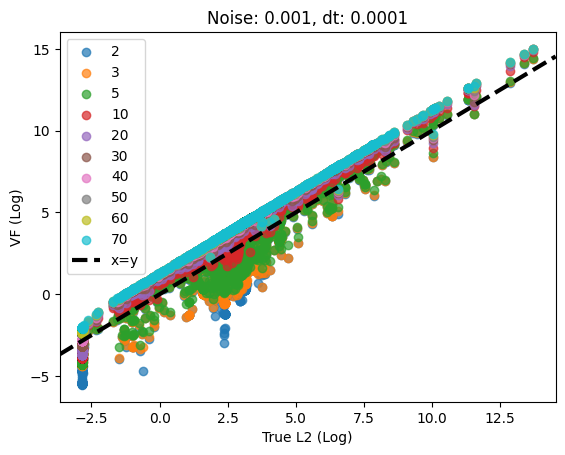

In [92]:
for num_basis in result_dict:
    # if num_basis < 20:
    #     continue
    # i = 10
    mse_L2s_trues, mse_VFs_eqs, _ = result_dict[num_basis]
    plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_VFs_eqs), 
                alpha=0.7,
                label=num_basis)
    
    # plt.scatter((mse_L2s_trues), (mse_VFs_eqs), 
    #             alpha=1,
    #             label=num_basis)
plt.xlabel("True L2 (Log)")
plt.ylabel(f"VF (Log)")
xpoints = ypoints = plt.xlim()
plt.plot(xpoints, ypoints, linestyle='--', color='k', lw=3, scalex=False, scaley=False, label="x=y")
# plt.title(f"Noise: {noise_ratio}")

plt.title(f"Noise: {noise_ratio}, dt: {dt}")
plt.legend()
plt.show()

# for num_points in result_dict:
#     # if num_points > 400:
#     #     continue
#     mse_L2s_trues, _, mse_L2s_eqs = result_dict[num_points]
#     plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_L2s_eqs), 
#                 alpha=0.3,
#                 label=num_points)
# plt.xlabel("True L2 (Log) ")
# plt.ylabel(f"L2 (Log)")
# plt.title(f"Noise: {noise_ratio}, dt: {dt}")
# plt.legend()
# plt.show()

/tmp/ipykernel_1518708/3293306536.py:7: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(1/num_basis), np.log(np.array(mse_L2s_trues[i])-np.array(mse_VFs_eqs[i])),


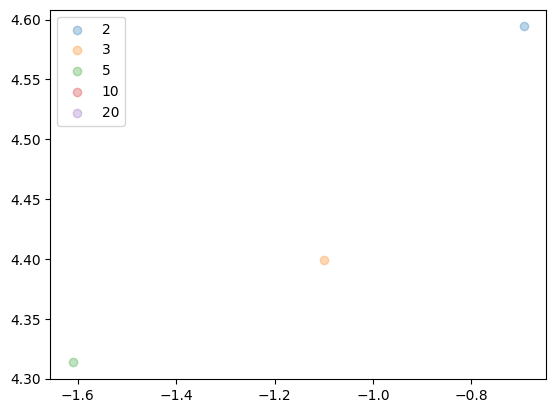

In [114]:
for num_basis in result_dict:
    if num_basis > 20:
        continue
    i = 10
    mse_L2s_trues, mse_VFs_eqs, _ = result_dict[num_basis]
    # plt.scatter(, np.log(np.array(mse_VFs_eqs)-np.array(mse_L2s_trues)), label=num_basis)
    plt.scatter(np.log(1/num_basis), np.log(np.array(mse_L2s_trues[i])-np.array(mse_VFs_eqs[i])), 
                label=num_basis, alpha=0.3)
plt.legend()
plt.show()

In [121]:
i=20
for num_basis in result_dict:
    print(result_dict[num_basis][0][i] - result_dict[num_basis][1][i])

-2853.1723355884487
-3237.057163759515
-3403.4614995699258
-6839.0354327041505
-7785.423860146623
-8129.301456443777
-8348.237189770716
-8470.719169413514
-8538.274820615727
-8574.828079111714


In [ ]:
result_dict = {}
for noise in [0.0, 0.008, 0.256]:
    result_dict[noise_ratio] = {}
    for task in ["Lotka_Volterra", "Lorenz", "SIR"]:
        result_dict[noise_ratio][task] = {}
        for num_basis in [50,100]:
            result_dict[noise_ratio][task][num_basis] = {}
            for num_points in [10,20,50,100,200,500]:
                train_samples, test_samples = [], []
                task_ode_num = 1
                num_env = 1    
                
                dt = 0.01 if num_points < 600 else 0.01 * 500 / num_points
                # dt = 0.0001
                time_string = "20240216_024249_980909" #get_now_string()
                args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                                 sample_strategy='uniform', params_strategy='default', 
                                 train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                                 save_folder='data/', train_sample_strategy='uniform', 
                                 use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=3, 
                                 dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                                 main_path='./',data_dir='data/', dt=dt)
                args.train_test_total_list = [num_points]
                
                ode = ODE_DICT.get(args.task)(args)
                ode.n = int(ode.params_config["t_max"] / dt)
                ode.t_series = np.linspace(ode.params_config["t_min"],
                    ode.params_config["t_max"] - dt, ode.n)
                ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
                ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
                ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
                ode.build()
                
                save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)
                
                info = None
                with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
                    info = json.load(f)
                
                for env in range(num_env):
                    trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
                    tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
                    trs = trs.sort_values(by='t', ascending=True)
                    tes = tes.sort_values(by='t', ascending=True)
                    train_samples.append(trs)
                    test_samples.append(tes)
                
                mse_L2s_eqs = []
                mse_VFs_eqs = []
                mse_VF_firsts = []
                mse_VF_seconds = []
                mse_L2s_trues = []
                print(ode.y[0][ode.train_indices_list[0]][[0,-1], 0])
                for eq in eqs[::]:
                    # eq = "C*x - C*x*y"
                    # eq = "C*x"
                    data_list = train_samples
                    _, found_eq, mse_L2, mse_VF, mse_VF_first, mse_VF_second, mse_L2s_true = score_with_est(eq, 11, data_list, reward_rescale=False,
                                   eta=0.99,
                                   error_tolerance=0.99,
                                   combine_rewards=combine_rewards_original,
                                   loss_func="L2",num_basis=num_basis,t_limit = 1e6)
                    if mse_L2:
                        mse_L2s_eqs.extend(mse_L2)
                        mse_VFs_eqs.extend(mse_VF)
                        mse_VF_firsts.extend(mse_VF_first)
                        mse_VF_seconds.extend(mse_VF_second)
                        mse_L2s_trues.extend(mse_L2s_true)
                    # break
                
                mse_VFs_eqs = np.array(mse_VFs_eqs)
                mse_VF_firsts = np.array(mse_VF_firsts)
                mse_VF_seconds = np.array(mse_VF_seconds)
                mse_L2s_eqs = np.array(mse_L2s_eqs)
                mse_L2s_trues = np.array(mse_L2s_trues)
                
                # plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_VFs_eqs), alpha=0.3)
                # plt.xlabel("True L2 distance ")
                # plt.ylabel(f"VF distance, noise: {noise_ratio}")
                # plt.show()
                
                # plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_L2s_eqs), alpha=0.3)
                # plt.xlabel("True L2 distance ")
                # plt.ylabel(f"L2 distance, noise: {noise_ratio} ")
                # plt.show()
            
                result_dict[noise][task][num_basis][num_points] = [mse_L2s_trues, mse_VFs_eqs, mse_L2s_eqs]

import pickle

with open("VF_L2_inspection_result.pkl", 'wb') as f:
    pickle.dump(result_dict, f)
# list(seen)

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.001
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.001, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.36it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


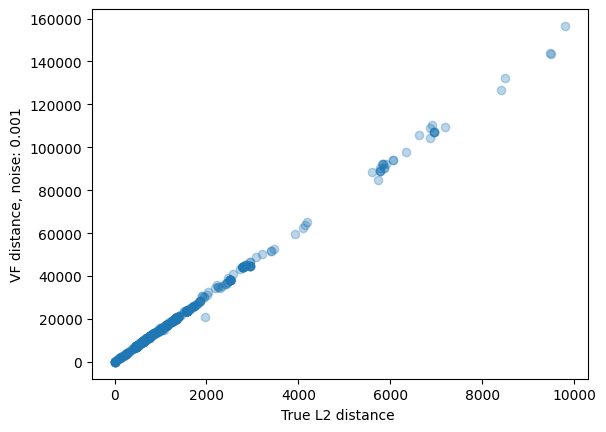

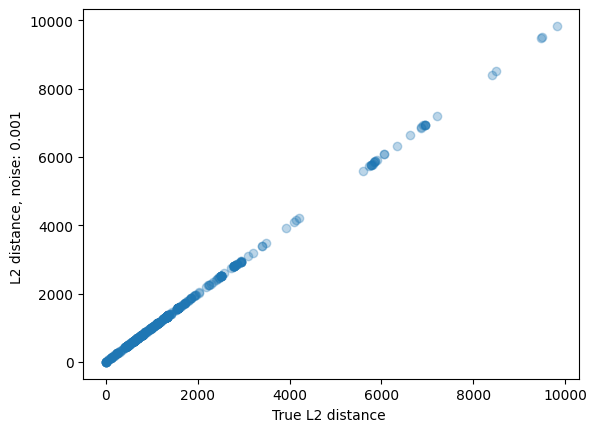

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.002
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.002, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.60it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


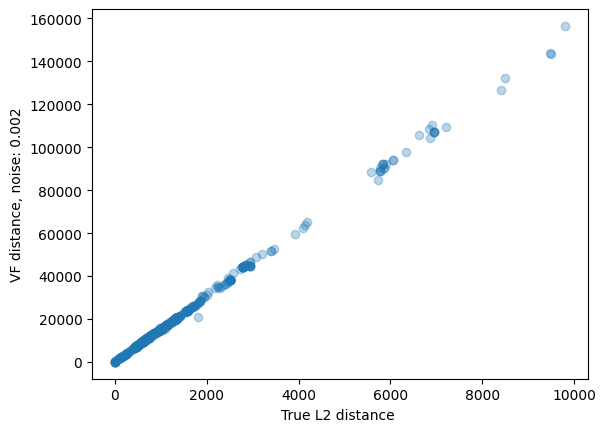

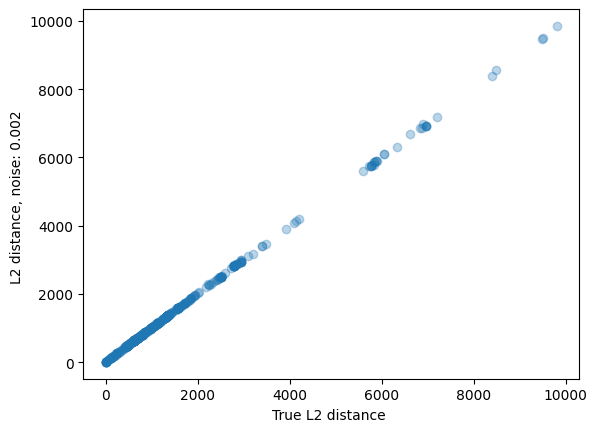

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.004
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.004, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.03it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


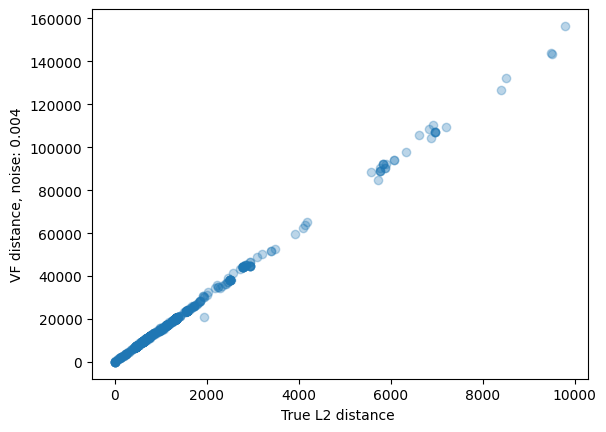

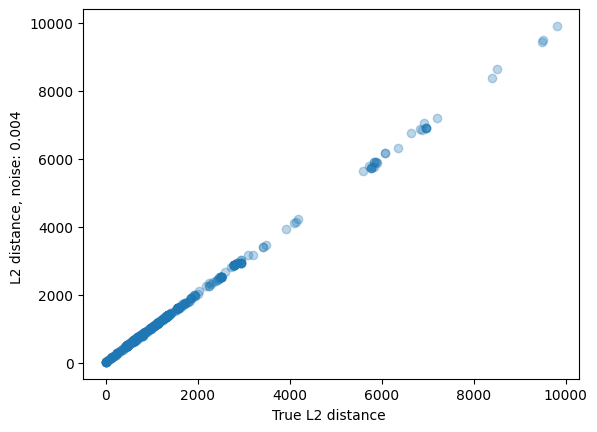

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.008
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.008, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.76it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


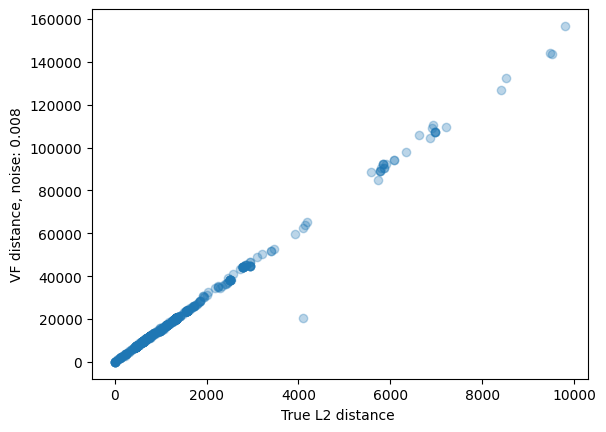

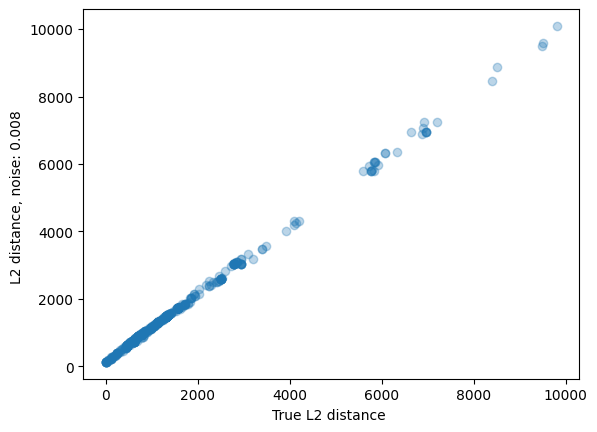

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.016
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.016, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.75it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


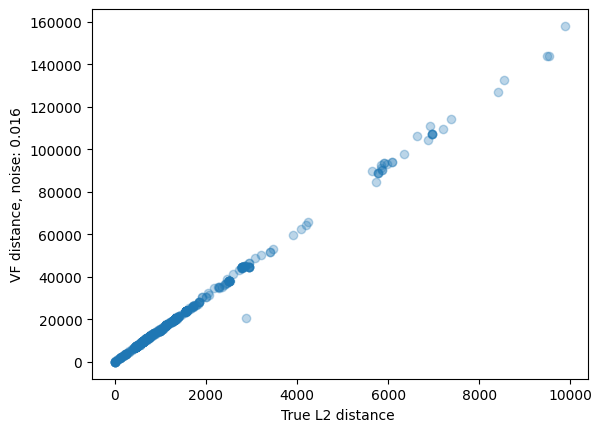

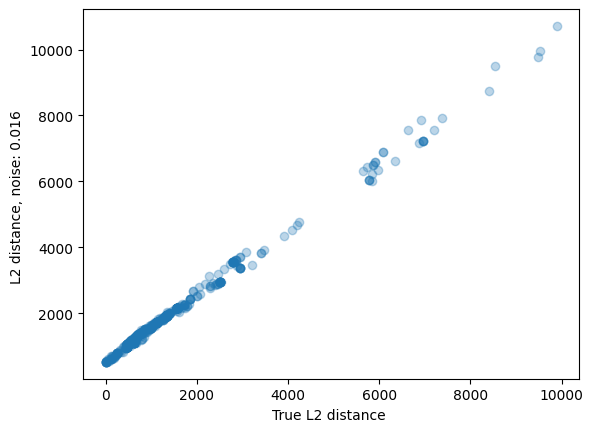

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.032
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.032, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.78it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


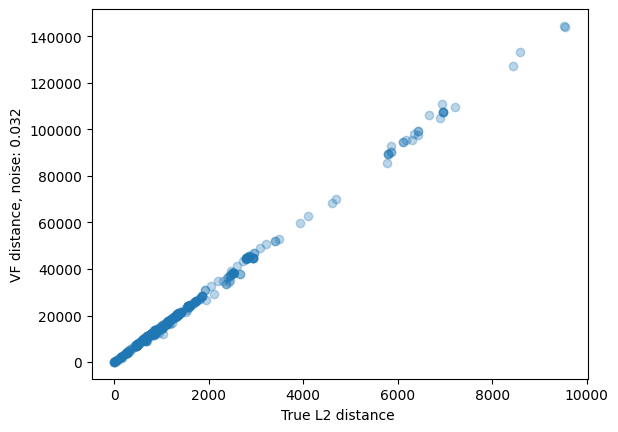

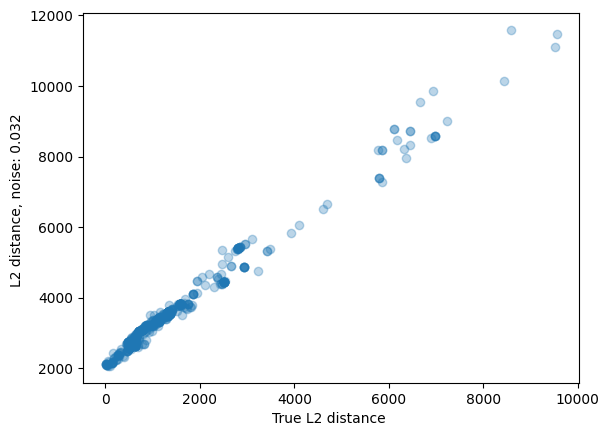

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.064
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.064, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.08it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


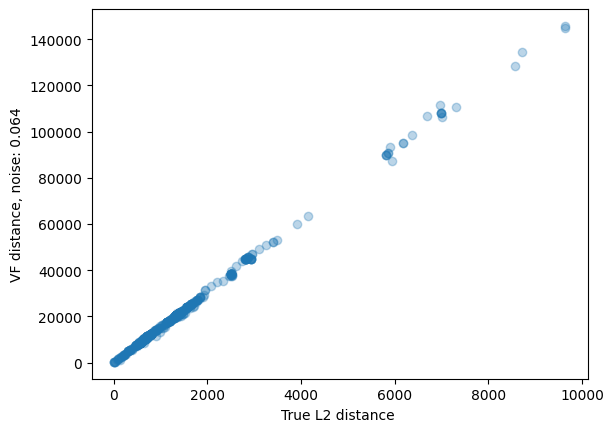

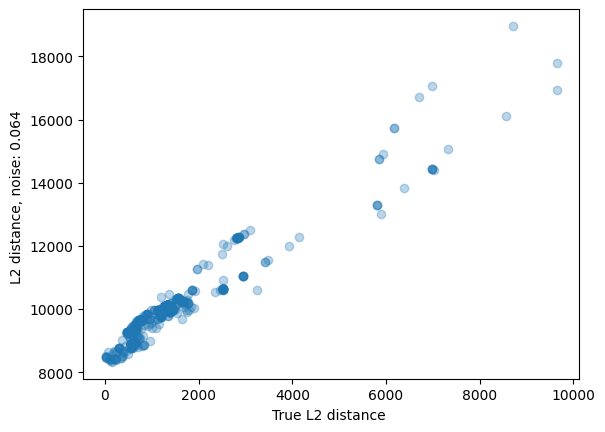

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.128
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.128, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.36it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


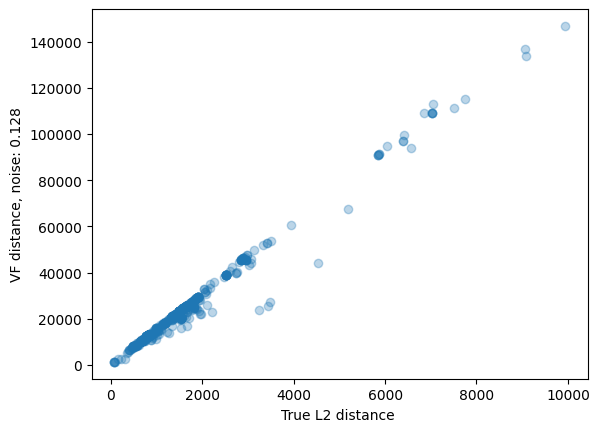

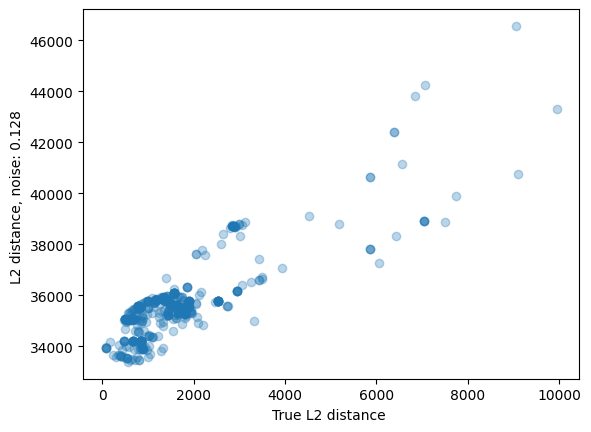

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.256
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.256, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.24s/it]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


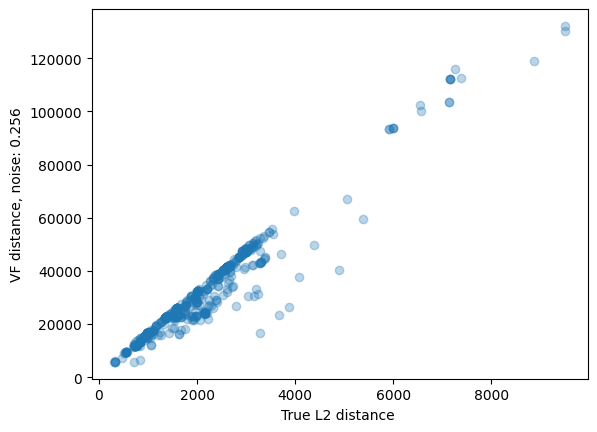

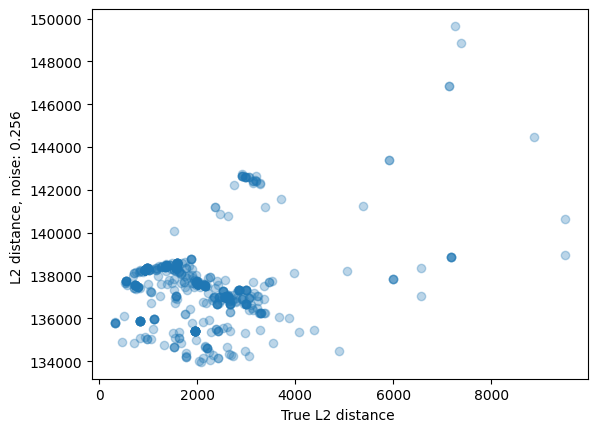

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 0.512
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 0.512, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.15it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


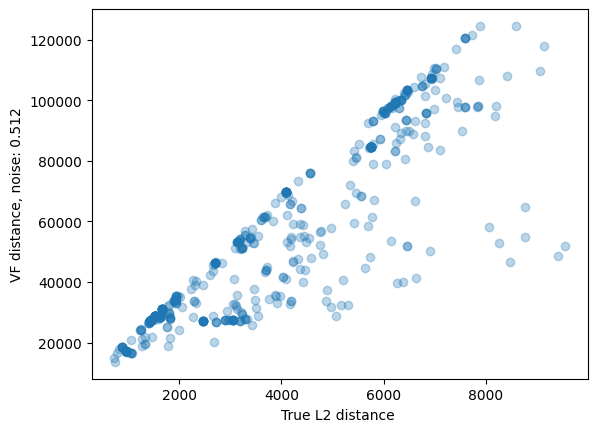

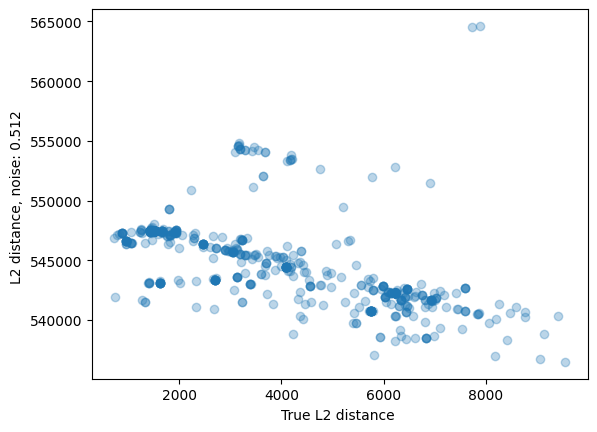

ode_name: Lotka_Volterra
num_env: 1
t_min: 0, t_max: 20, dt: 0.01
train_test_total_list: [500]
Environment 00: train set: 400 (80.0 %), test set: 100 (20.0 %), train_test_total: 500, n_total: 2000
noise ratio: 1.024
save_folder: ./data/Lotka_Volterra/20240216_024249_980909
{'params': {'0': [1.0, 0.3, 3.0, 0.1]}, 'y0': {'0': [10.0, 5.0]}, 'noise_ratio': 1.024, 'log_truth_ode_list': []}
Environment 00: params=['1.00000000', '0.30000000', '3.00000000', '0.10000000'], y0=['10.00000000', '5.00000000'], truth = ['1.0*x-0.3*x*y', '0.1*x*y-3.0*y']


100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.13it/s]


[10.         50.79176311]


<string>:1: RuntimeWarning: divide by zero encountered in divide
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2989: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3512: RuntimeWarning: invalid value encountered in scalar subtract
  if (fx2 - fval) > delta:
/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/scipy/optimize/_optimize.py:3522: RuntimeWarning: invalid value encountered in scalar subtract
  if 2.0 * (fx - fval) <= bnd:
/tmp/ipykernel_233869/3872245466.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = f * g[..., newaxis] + X * dg[..., newaxis]
/tmp/ipykernel_233869/3872245466.py:110: RuntimeWarning: invalid value encountered in multiply
  first = f * g[..., newaxis]
<string>:1: RuntimeWarning: invalid value encountered in divide


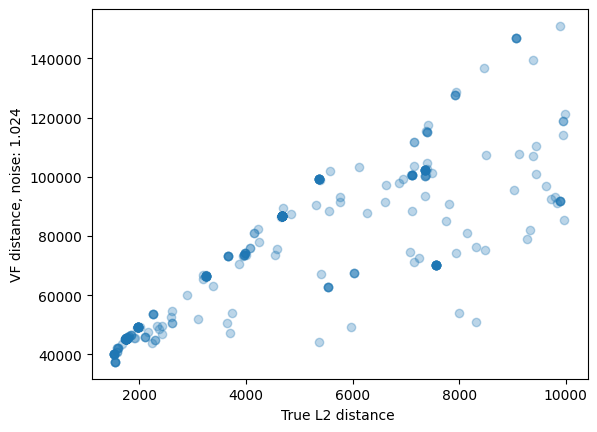

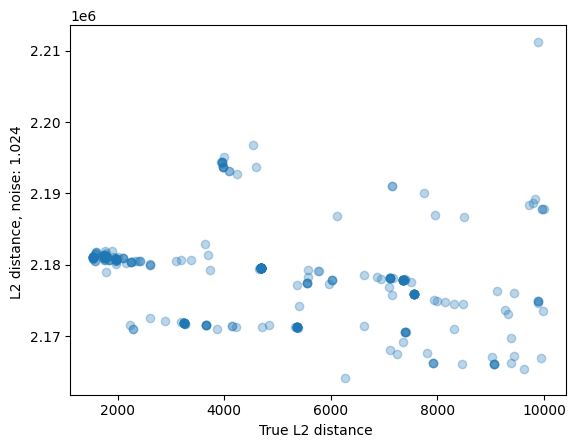

In [549]:
for noise_ratio in [0.001*2**i for i in range(11)]:
    # noise_ratio = 0.08
    num_points = 500
    num_basis = 50
    train_samples, test_samples = [], []
    task = "Lotka_Volterra"
    # task = "Lorenz"
    # task = "SIR"
    # task = "Fluid_Flow"
    # task = "Fluid_Flow"
    # task = "Repressilator3"
    # task = "Glycolytic_Oscillator"
    
    task_ode_num = 1
    num_env = 1    
    
    dt = 0.01 if num_points < 600 else 0.01 * 500 / num_points
    time_string = "20240216_024249_980909" #get_now_string()
    args = argparse.Namespace(task=task, num_env=num_env, seed=1, noise_ratio=noise_ratio, 
                     sample_strategy='uniform', params_strategy='default', 
                     train_test_total="default_0", train_ratio=0.8, save_figure=0, 
                     save_folder='data/', train_sample_strategy='uniform', 
                     use_new_reward=0, loss_func='VF', num_run=1, task_ode_num=3, 
                     dataset_sparse='sparse', dataset_gp=0, time_string=time_string,
                     main_path='./',data_dir='data/', dt=dt)
    args.train_test_total_list = [num_points]
    
    ode = ODE_DICT.get(args.task)(args)
    ode.n = int(ode.params_config["t_max"] / dt)
    ode.t_series = np.linspace(ode.params_config["t_min"],
        ode.params_config["t_max"] - dt, ode.n)
    ode.y = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.y_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.dy_noise = np.zeros([ode.args.num_env, ode.n, ode.ode_dim])
    ode.build()
    
    save_folder = os.path.join(ode.args.save_folder, ode.ode_name, ode.args.time_string)
    
    info = None
    with open(os.path.join(save_folder, task + f'_info.json'), 'r') as f:
        info = json.load(f)
    
    for env in range(num_env):
        trs = pd.read_csv(os.path.join(save_folder, task + f'_train_{env}.csv'))
        tes = pd.read_csv(os.path.join(save_folder, task + f'_test_{env}.csv'))
        trs = trs.sort_values(by='t', ascending=True)
        tes = tes.sort_values(by='t', ascending=True)
        train_samples.append(trs)
        test_samples.append(tes)
    
    mse_L2s_eqs = []
    mse_VFs_eqs = []
    mse_VF_firsts = []
    mse_VF_seconds = []
    mse_L2s_trues = []
    print(ode.y[0][ode.train_indices_list[0]][[0,-1], 0])
    for eq in eqs:
        # eq = "C*x - C*x*y"
        # eq = "C*x"
        data_list = train_samples
        _, found_eq, mse_L2, mse_VF, mse_VF_first, mse_VF_second, mse_L2s_true = score_with_est(eq, 11, data_list, reward_rescale=False,
                       eta=0.99,
                       error_tolerance=0.99,
                       combine_rewards=combine_rewards_original,
                       loss_func="L2",num_basis=num_basis,t_limit = 1e6)
        if mse_L2:
            mse_L2s_eqs.extend(mse_L2)
            mse_VFs_eqs.extend(mse_VF)
            mse_VF_firsts.extend(mse_VF_first)
            mse_VF_seconds.extend(mse_VF_second)
            mse_L2s_trues.extend(mse_L2s_true)
        # break
    
    mse_VFs_eqs = np.array(mse_VFs_eqs)
    mse_VF_firsts = np.array(mse_VF_firsts)
    mse_VF_seconds = np.array(mse_VF_seconds)
    mse_L2s_eqs = np.array(mse_L2s_eqs)
    mse_L2s_trues = np.array(mse_L2s_trues)
    
    n = 4
    # plt.scatter(np.log10(mse_L2s_eqs), np.log10(mse_VF_firsts))
    # plt.scatter(np.log10(mse_L2s_eqs), np.log10(mse_VF_seconds), alpha=0.3)
    # plt.scatter(np.log10(mse_L2s_eqs), np.log10(mse_VFs_eqs), alpha=0.3)
    # plt.scatter((mse_L2s_eqs[np.log10(mse_L2s_eqs) < n]), (mse_VF_firsts[np.log10(mse_L2s_eqs) < n]))
    # plt.scatter((mse_L2s_eqs[np.log10(mse_L2s_eqs) < n]), (mse_VF_seconds[np.log10(mse_L2s_eqs) < n]), alpha=0.3)
    plt.scatter((mse_L2s_trues[np.log10(mse_L2s_trues) < n]), (mse_VFs_eqs[np.log10(mse_L2s_trues) < n]), alpha=0.3)
    plt.xlabel("True L2 distance ")
    plt.ylabel(f"VF distance, noise: {noise_ratio}")
    plt.show()
    
    plt.scatter((mse_L2s_trues[np.log10(mse_L2s_trues) < n]), (mse_L2s_eqs[np.log10(mse_L2s_trues) < n]), alpha=0.3)
    plt.xlabel("True L2 distance ")
    plt.ylabel(f"L2 distance, noise: {noise_ratio} ")
    plt.show()

In [22]:
import pickle

with open("../Invariant_Physics/notebooks/inspection_result_Lotka_Volterra.pkl", 'rb') as f:
    results = pickle.load(f)
results.keys(), results[0.0].keys(), results[0.0]['SIR'].keys(), results[0.0]['SIR'][50].keys()

(dict_keys([0.0, 0.008, 0.256]),
 dict_keys(['Lotka_Volterra', 'Lorenz', 'SIR']),
 dict_keys([50, 100]),
 dict_keys([10, 20, 50, 100, 200, 500]))

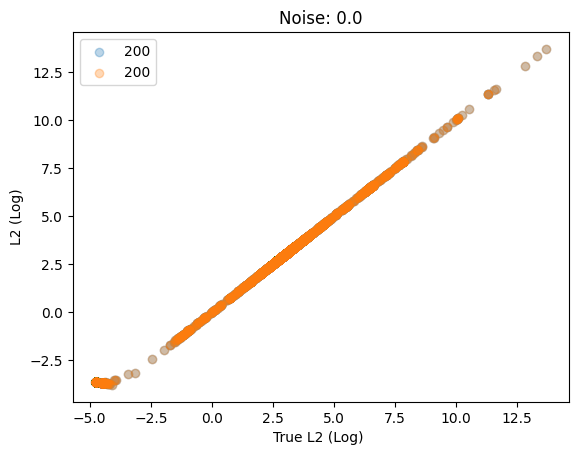

In [105]:
noise_ratio = 0.00
num_basis = 50
d = results[noise_ratio]['Lotka_Volterra'][num_basis]

# for num_points in d:
#     mse_L2s_trues, mse_VFs_eqs, _ = d[num_points]
#     plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_VFs_eqs), 
#                 alpha=0.3,
#                 label=num_points)
# plt.xlabel("True L2 (Log)")
# plt.ylabel(f"VF (Log)")
# plt.title(f"Noise: {noise_ratio}, num basis: {num_basis}")
# plt.legend()
# plt.show()

noise_ratio = 0.00
num_basis = 100
d = results[noise_ratio]['Lotka_Volterra'][num_basis]
for num_points in d:
    if num_points != 200:
        continue
    mse_L2s_trues, _, mse_L2s_eqs = d[num_points]
    plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_L2s_eqs), 
                alpha=0.3,
                label=num_points)
# plt.xlabel("True L2 (Log) ")
# plt.ylabel(f"L2 (Log)")
# plt.title(f"Noise: {noise_ratio}")
# plt.legend()
# plt.show()

noise_ratio = 0.0
num_basis = 50
d = results[noise_ratio]['Lotka_Volterra'][num_basis]
for num_points in d:
    if num_points != 200:
        continue
    mse_L2s_trues, _, mse_L2s_eqs = d[num_points]
    plt.scatter(np.log10(mse_L2s_trues), np.log10(mse_L2s_eqs), 
                alpha=0.3,
                label=num_points)
plt.xlabel("True L2 (Log) ")
plt.ylabel(f"L2 (Log)")
plt.title(f"Noise: {noise_ratio}")
plt.legend()
plt.show()

In [39]:
1/(1+1e6)  

9.99999000001e-07

In [68]:
(f_prime(tspan) * gs).shape

(49, 100)

In [69]:
(f_prime(tspan).reshape(-1,1) * gs[..., newaxis]).shape

(49, 100, 1)

In [70]:
(s @ tspan.reshape(1, -1)).shape

(49, 100)

In [129]:
from scipy.interpolate import UnivariateSpline
f = lambda x: -x**2 + 2*x
f_prime = lambda x: -2*x + 2


tspan = np.linspace(0, 20, 100)
T = tspan[-1]
s = np.arange(1, 50, 1.0).reshape((-1, 1))[:, :] # s = 1
funcs_input = np.pi * s @ tspan.reshape((1, -1)) / T
print(funcs_input.shape)
# print(tspan)
gs = np.sqrt(2 / T) * np.sin(funcs_input)
dgs = np.pi * s / T * np.sqrt(2 / T) * np.cos(funcs_input)

first = f_prime(tspan).reshape(-1,1) * gs[..., np.newaxis]
second = f(tspan).reshape(-1,1) * dgs[..., np.newaxis]
print(first.shape)
first = simpson(first, float(tspan[1] - tspan[0]), dim = 1)
second = simpson(second, float(tspan[1] - tspan[0]), dim = 1)

# \int_0^T f_prime(t) * gs(t) dt = -\int_0^T f(t) * dgs(t) dt + f(T)g(T) - f(0)g(0) 
# print((f_prime(tspan) * gs).shape)
# print(np.sum(f_prime(tspan) * gs * (tspan[1]-tspan[0])), np.sum(f(tspan) * dgs * (tspan[1]-tspan[0])))
# print(f(tspan[0])*gs[0,0], f(T)*gs[0,-1])
print(first, second)
print(first + second)
print(((first+second)**2).sum())
# print(((first-first_fine)**2).sum())
# print(((second+first_fine)**2).sum())

# tspan = np.linspace(0, 20, 10000)
# T = tspan[-1]
# s = np.arange(1, 50, 1.0).reshape((-1, 1))[:, :] # s = 1
# funcs_input = pi * s @ tspan.reshape((1, -1)) / T
# print(funcs_input.shape)
# # print(tspan)
# gs = ((pi * s)) *  np.sqrt(2 / T) * np.sin(funcs_input)
# dgs = np.sqrt(2 / T)/T * np.cos(funcs_input)

# first = f_prime(tspan).reshape(-1,1) * gs[..., np.newaxis]
# second = f(tspan).reshape(-1,1) * dgs[..., np.newaxis]
# first = simpson(first, float(tspan[1] - tspan[0]), dim = 1)
# second = simpson(second, float(tspan[1] - tspan[0]), dim = 1)

# print(first, second)
# print(((first-first_fine)**2).sum())
# print(((second+first_fine)**2).sum())

# plt.plot(tspan.reshape(-1, 1), gs.T[:,:8])
# plt.show()
# plt.plot(tspan.reshape(-1, 1), dgs.T[:,:8])
# plt.show()
# plt.plot(tspan.reshape(-1, 1), (gs+dgs).T[:,:8])
# plt.show()

(49, 100)
(49, 100, 1)
tensor([-72.4741,  40.2634, -24.1580,  20.1317, -14.4949,  13.4213, -10.3536,
         10.0662,  -8.0532,   8.0534,  -6.5895,   6.7120,  -5.5768,   5.7545,
         -4.8349,   5.0373,  -4.2685,   4.4807,  -3.8227,   4.0369,  -3.4636,
          3.6758,  -3.1690,   3.3773,  -2.9241,   3.1275,  -2.7184,   2.9165,
         -2.5444,   2.7373,  -2.3965,   2.5843,  -2.2705,   2.4535,  -2.1630,
          2.3414,  -2.0712,   2.2454,  -1.9929,   2.1630,  -1.9260,   2.0922,
         -1.8687,   2.0311,  -1.8191,   1.9776,  -1.7756,   1.9301,  -1.7363],
       dtype=torch.float64) tensor([ 72.4741, -40.2634,  24.1580, -20.1317,  14.4948, -13.4213,  10.3540,
        -10.0670,   8.0551,  -8.0568,   6.5956,  -6.7211,   5.5908,  -5.7741,
          4.8624,  -5.0733,   4.3160,  -4.5394,   3.8962,  -4.1233,   3.5664,
         -3.7908,   3.2986,  -3.5136,   3.0677,  -3.2649,   2.8473,  -3.0158,
          2.6070,  -2.7324,   2.3108,  -2.3745,   1.9149,  -1.8937,   1.3673,
         -1.

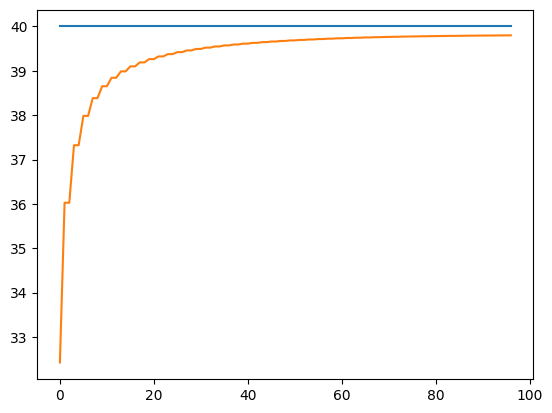

In [250]:
from scipy.interpolate import UnivariateSpline
f = lambda x: -x**2 + 2*x
f_prime = lambda x: -2*x + 2
f_hat = lambda x: -2*x

# f = lambda x: -x**2 
# f_prime = lambda x: -2*x 
# f_hat = lambda x: -x


tspan = np.linspace(0, 10, 500)
true_tspan = np.linspace(0, tspan[-1], 10000)
true_L2 = simpson((f_prime(true_tspan) - f_hat(true_tspan))**2, float(true_tspan[1]-true_tspan[0]), dim=0)
T = tspan[-1]

VFs = []
true_L2s = []
for max_s in range(3,100):
    s = np.arange(1, max_s, 1.0).reshape((-1, 1))[:, :] # s = 1
    funcs_input = np.pi * s @ tspan.reshape((1, -1)) / T
    # print(funcs_input.shape)
    # print(tspan)
    gs = np.sqrt(2 / T) * np.sin(funcs_input)
    dgs = np.pi * s / T * np.sqrt(2 / T) * np.cos(funcs_input)
    # dgs = s/s
    
    first = f_hat(tspan).reshape(-1,1) * gs[..., np.newaxis]
    second = f(tspan).reshape(-1,1) * dgs[..., np.newaxis]
    # second = -f_prime(tspan).reshape(-1,1) * gs[..., np.newaxis]
    first = simpson(first, float(tspan[1] - tspan[0]), dim = 1)
    second = simpson(second, float(tspan[1] - tspan[0]), dim = 1)
    
    # \int_0^T f_prime(t) * gs(t) dt = -\int_0^T f(t) * dgs(t) dt + f(T)g(T) - f(0)g(0) 
    # print((f_prime(tspan) * gs).shape)
    # print(np.sum(f_prime(tspan) * gs * (tspan[1]-tspan[0])), np.sum(f(tspan) * dgs * (tspan[1]-tspan[0])))
    # print(f(tspan[0])*gs[0,0], f(T)*gs[0,-1])
    # print(first, second)
    # print(first + second)
    # print(((first+second)**2).sum
    # true_L2 = simpson((f_prime(tspan) - f_hat(tspan))**2, float(tspan[1]-tspan[0]), dim=0)
    VF = ((first+second)**2).sum()
    # true_L2 = ((f_prime(tspan) - f_hat(tspan))**2*float(tspan[1] - tspan[0])).sum()
    # true_L2 = ((f_prime(tspan) - f_hat(tspan))**2).sum()/len(tspan) 
    # VF = ((first+second)**2/len(tspan)).sum()
    true_L2s.append(true_L2)
    VFs.append(VF)

plt.plot(range(len(true_L2s)), true_L2s)
plt.plot(range(len(VFs)), VFs)

plt.show()

In [236]:
true_L2

tensor(0., dtype=torch.float64)

In [207]:
(first+second)**2

tensor([3.2423e+00, 8.1057e-01, 3.6025e-01, 2.0264e-01, 1.2969e-01, 9.0063e-02,
        6.6169e-02, 5.0661e-02, 4.0028e-02, 3.2423e-02, 2.6796e-02, 2.2516e-02,
        1.9185e-02, 1.6542e-02, 1.4410e-02, 1.2665e-02, 1.1219e-02, 1.0007e-02,
        8.9818e-03, 8.1062e-03, 7.3527e-03, 6.6997e-03, 6.1300e-03, 5.6300e-03,
        5.1889e-03, 4.7978e-03, 4.4494e-03, 4.1376e-03, 3.8577e-03, 3.6053e-03,
        3.3771e-03, 3.1699e-03, 2.9814e-03, 2.8094e-03, 2.6520e-03, 2.5076e-03,
        2.3749e-03, 2.2527e-03, 2.1398e-03, 2.0354e-03, 1.9387e-03, 1.8489e-03,
        1.7655e-03, 1.6878e-03, 1.6154e-03, 1.5478e-03, 1.4847e-03, 1.4256e-03,
        1.3703e-03, 1.3184e-03, 1.2698e-03, 1.2241e-03, 1.1812e-03, 1.1408e-03,
        1.1028e-03, 1.0671e-03, 1.0334e-03, 1.0017e-03, 9.7179e-04, 9.4363e-04,
        9.1708e-04, 8.9206e-04, 8.6847e-04, 8.4624e-04, 8.2530e-04, 8.0557e-04,
        7.8700e-04, 7.6953e-04, 7.5310e-04, 7.3767e-04, 7.2319e-04, 7.0962e-04,
        6.9692e-04, 6.8505e-04, 6.7398e-

In [215]:
true_L2s[-1]-VFs[-1]

tensor(29.9829, dtype=torch.float64)

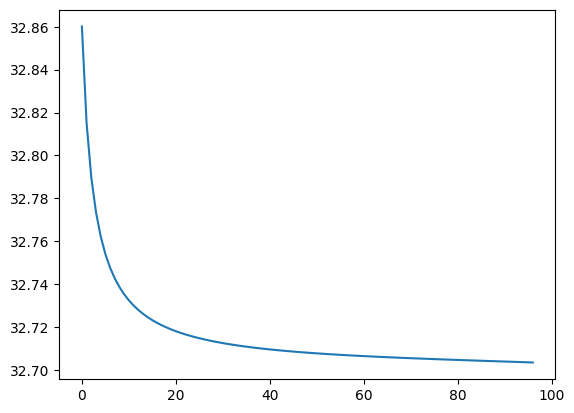

In [220]:
# plt.plot(range(len(VFs)), np.array(true_L2s)-np.array(VFs))
plt.plot(range(len(VFs)), (np.array(true_L2s)-np.array(VFs))*np.arange(3,100))
plt.show()

In [ ]:
first.shape, second.shape

In [242]:
# first_fine = first.clone()

[18.18181818 18.38383838 18.58585859 18.78787879 18.98989899 19.19191919
 19.39393939 19.5959596  19.7979798  20.        ]
1.6751687205268772e-09 6.34813984912357e-13
False
20.2020202020202


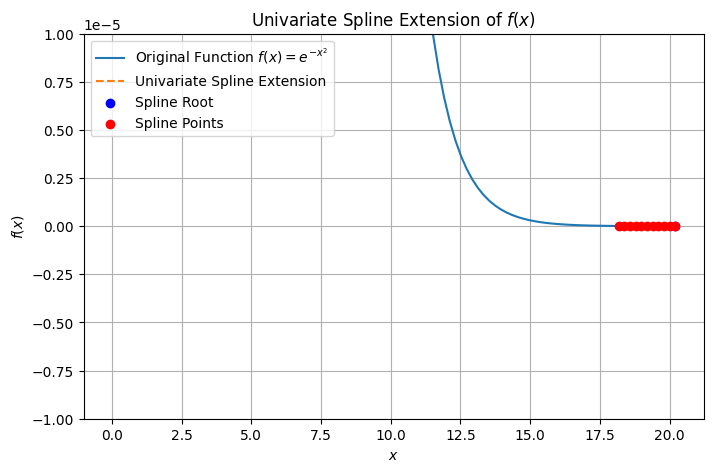

In [286]:
f = lambda x: np.exp(-x)
f_prime = lambda x: -2*x + 2

from scipy.interpolate import UnivariateSpline
from scipy.optimize import bisect

# Cutoff point and generate points
tspan = np.linspace(0, 20, 100)
x_0 = tspan[-1]
x = tspan
y = f(tspan)

# Points near x_0 and synthetic point
x_near_x0 = tspan[-10:]
y_near_x0 = y[-10:]
print(x_near_x0)
eps = 1e-3  # Small distance beyond x_0

# x_spline_points = np.append(x_near_x0, x_0 + eps)
# y_spline_points = np.append(y_near_x0, 0)

# # Fit a Univariate Spline
# weights = np.ones(x_spline_points.shape)
# weights[-1] = 0.1
# us = UnivariateSpline(x_spline_points, y_spline_points, s=1e6, k=3,
#                       w=weights)

# # We know the root should be near x_0 + eps, so we search in a small interval around this point
# interval_start = x_0
# us0_g0 = us(interval_start) > 0
# for i in range(-6,6):
#     interval_end = x_0 + eps + 2**i  # Slightly larger to ensure we encompass the root
#     us1_g0 = us(interval_end) > 0
#     if (us0_g0 and us1_g0) or (not us0_g0 and not us1_g0):
#         continue
#     else:
#         pass

dx = tspan[1] - tspan[0] 
for i in range(0,8):
    dist = dx * 2**i
    new_point = x_0 + dist
    x_spline_points = np.append(x_near_x0, new_point)
    y_spline_points = np.append(y_near_x0, 0)
    
    # Fit a Univariate Spline
    # us = UnivariateSpline(x_spline_points, y_spline_points, s=1, k=3) 
    weights = np.ones(x_spline_points.shape)
    weights[-1] = 0.01
    us = UnivariateSpline(x_spline_points, y_spline_points, s=1e6, k=5,
                          w=weights)

    # Check fitness
    dist_x0 = np.abs(us(x_0) - y[-1])
    dist_root = np.abs(us(new_point))
    print(dist_root, dist_x0)
    print(dist_x0 > eps)

    if dist_x0 > eps or dist_root > eps:
        pass
    else:
        print(new_point)
        break
root_bisect = new_point


# Plotting
x_extended_us = np.linspace(x_0-dx, root_bisect+0.01, 100)
y_extended_us = us(x_extended_us)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Original Function $f(x) = e^{-x^2}$')
plt.plot(x_extended_us, y_extended_us, '--', label='Univariate Spline Extension')
plt.scatter([root_bisect], [0], color='b', label="Spline Root")
plt.scatter(x_spline_points, y_spline_points, color='red', zorder=5, label='Spline Points')
# f = lambda x: np.where(x <= 20, -x**2 + 2*x, us(x))
# tspan = np.linspace(0, root_bisect, 1000)
# plt.plot(tspan, f(tspan))
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Univariate Spline Extension of $f(x)$')
plt.legend()
plt.ylim([-0.00001,0.00001])
# plt.ylim([min(y)-5*abs(min(y)), max(y)+0.1*max(y)+10])
plt.grid(True)
plt.show()

In [275]:
us.derivative(3)

In [266]:
eqs[:10]

['(x-(((x*((y*C)*C))-((((y*((y/y)-(x+((x*y)*C))))*C)*C)*(((x*y)*C)*C)))-((((x/y)+(x+y))+((x/x)*y))*x)))',
 '((y*C)+((x-x)+y))',
 '((x-((y*C)*C))*C)',
 '(x-((((x*C)+x)-y)-(y*x)))',
 '(x+((x/y)/x))',
 '(x-((x+x)-(x-((x+(y*C))*C))))',
 '(((y*(y+y))*C)*C)',
 '((y*C)-((((y/y)*C)*x)/x))',
 '((y/((y*C)-x))/(x+y))',
 '(x+(y-(x/y)))']

In [274]:
f_prime(20-1e-6)

array(-37.999998)

(49, 100)


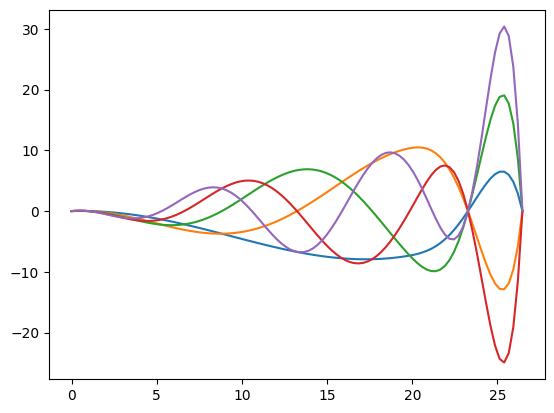

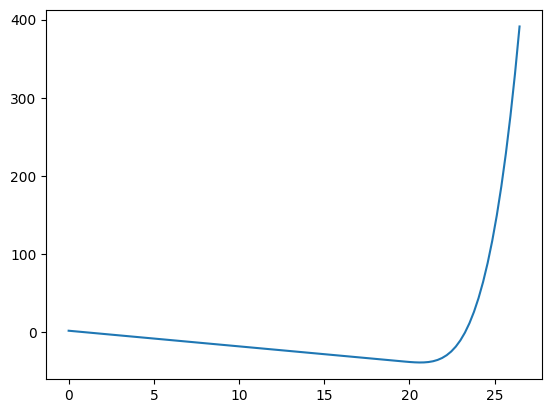

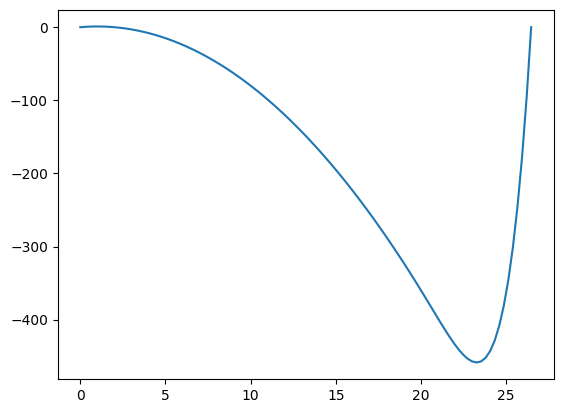

tensor([-87.9189,  12.4841,  30.8002, -52.9451,  70.7702, -77.9105,  82.8828,
        -81.3674,  79.7433, -74.7565,  71.1928, -66.0333,  62.7789, -58.5164,
         55.9625, -52.4787,  50.4013, -47.4408,  45.7055, -43.1804,  41.7622,
        -39.6228,  38.4702, -36.6316,  35.6724, -34.0642,  33.2590, -31.8485,
         31.1807, -29.9422,  29.3883, -28.2891,  27.8236, -26.8389,  26.4485,
        -25.5656,  25.2425, -24.4478,  24.1794, -23.4562,  23.2297, -22.5654,
         22.3736, -21.7602,  21.5970, -21.0244,  20.8800, -20.3358,  20.2004],
       dtype=torch.float64) tensor([ 87.9188, -12.4840, -30.8001,  52.9442, -70.7673,  77.9040, -82.8702,
         81.3462, -79.7102,  74.7084, -71.1249,  65.9412, -62.6557,  58.3556,
        -55.7544,  52.2155, -50.0708,  47.0341, -45.2077,  42.5811, -41.0432,
         38.7726, -37.4672,  35.4645, -34.3172,  32.5108, -31.4817,  29.8393,
        -28.9122,  27.4101, -26.5643,  25.1751, -24.3922,  23.1009, -22.3787,
         21.1852, -20.5291,  19.436

In [280]:
tspan = np.linspace(0, 20, 100)

us_derivative = us.derivative(1)
f = lambda x: np.where(x <= 20, -x**2 + 2*x, us(x))
f_prime = lambda x: np.where(x <= 20, -2*x + 2, us_derivative(x))

# tspan = np.linspace(0, 20, 100)
tspan = np.linspace(0, root_bisect, 100)

T = tspan[-1]
# T = root_bisect
s = np.arange(1, 50, 1.0).reshape((-1, 1))[:50, :] # s = 1
funcs_input = np.pi * s @ tspan.reshape((1, -1)) / T
print(funcs_input.shape)
gs = np.sqrt(2 / T) * np.sin(funcs_input)
dgs = np.pi * s / T * np.sqrt(2 / T) * np.cos(funcs_input)

first = f_prime(tspan).reshape(-1,1) * gs[..., np.newaxis]
second = f(tspan).reshape(-1,1) * dgs[..., np.newaxis]

plt.plot(tspan.reshape(-1), first[:5,:].squeeze().T)
plt.show()
plt.plot(tspan, f_prime(tspan))
plt.show()
plt.plot(tspan, f(tspan))
plt.show()

first = simpson(first, float(tspan[1] - tspan[0]), dim = 1)
second = simpson(second, float(tspan[1] - tspan[0]), dim = 1)
print(first, second)
print(first + second)
print(((first+second)**2).sum())
# print(((second+first_fine)**2).sum())

In [205]:
x_spline_points, y_spline_points

(array([18.18181818, 18.38383838, 18.58585859, 18.78787879, 18.98989899,
        19.19191919, 19.39393939, 19.5959596 , 19.7979798 , 20.        ,
        45.85858586]),
 array([-294.21487603, -301.19783696, -308.2624222 , -315.40863177,
        -322.63646567, -329.94592389, -337.33700643, -344.80971329,
        -352.36404449, -360.        ,    0.        ]))

In [120]:
us(26)

array(627.95525121)

In [87]:
f(tspan)

array([ 0.00000000e+00,  3.63228242e-01,  6.44832160e-01,  8.44811754e-01,
        9.63167024e-01,  9.99897970e-01,  9.55004591e-01,  8.28486889e-01,
        6.20344863e-01,  3.30578512e-01, -4.08121620e-02, -4.93827160e-01,
       -1.02846648e+00, -1.64473013e+00, -2.34261810e+00, -3.12213039e+00,
       -3.98326701e+00, -4.92602796e+00, -5.95041322e+00, -7.05642281e+00,
       -8.24405673e+00, -9.51331497e+00, -1.08641975e+01, -1.22967044e+01,
       -1.38108356e+01, -1.54065912e+01, -1.70839710e+01, -1.88429752e+01,
       -2.06836037e+01, -2.26058565e+01, -2.46097337e+01, -2.66952352e+01,
       -2.88623610e+01, -3.11111111e+01, -3.34414856e+01, -3.58534843e+01,
       -3.83471074e+01, -4.09223549e+01, -4.35792266e+01, -4.63177227e+01,
       -4.91378431e+01, -5.20395878e+01, -5.50229568e+01, -5.80879502e+01,
       -6.12345679e+01, -6.44628099e+01, -6.77726763e+01, -7.11641669e+01,
       -7.46372819e+01, -7.81920212e+01, -8.18283849e+01, -8.55463728e+01,
       -8.93459851e+01, -

In [ ]:
# tensor([-4.6138e+02,  1.2816e+02, -5.1265e+01,  3.2041e+01, -1.8455e+01,
#          1.4240e+01, -9.4160e+00,  8.0101e+00, -5.6961e+00,  5.1265e+00,
#         -3.8131e+00,  3.5601e+00, -2.7301e+00,  2.6156e+00, -2.0506e+00,
#          2.0025e+00, -1.5965e+00,  1.5823e+00, -1.2781e+00,  1.2816e+00,
#         -1.0462e+00,  1.0592e+00, -8.7218e-01,  8.9002e-01, -7.3821e-01,
#          7.5836e-01, -6.3290e-01,  6.5389e-01, -5.4861e-01,  5.6961e-01,
#         -4.8011e-01,  5.0063e-01, -4.2368e-01,  4.4347e-01, -3.7664e-01,
#          3.9556e-01, -3.3702e-01,  3.5502e-01, -3.0334e-01,  3.2041e-01,
#         -2.7447e-01,  2.9062e-01, -2.4953e-01,  2.6480e-01, -2.2784e-01,
#          2.4227e-01, -2.0887e-01,  2.2250e-01, -1.9216e-01],
#        dtype=torch.float64)

In [659]:
def wrap_to_pi(x):
    # Maps x to the [-pi, pi] range
    return (x + np.pi) % (2 * np.pi) - np.pi
i = 20
something = wrap_to_pi(i)
np.cos(something) - np.cos(i)

-6.661338147750939e-16

In [301]:
integral_lhs = np.trapz(f_prime(tspan) * gs, tspan)
integral_rhs = np.trapz(f(tspan) * dgs, tspan)
boundary_terms = f(T)*gs[0,-1] - f(tspan[0])*gs[0,0]

# Calculate and print the results
result_difference = integral_lhs - (-integral_rhs + boundary_terms)
integral_lhs+integral_rhs, boundary_terms, result_difference

(array([-2.10720384]), -2.1029244484765277, array([-0.00427939]))

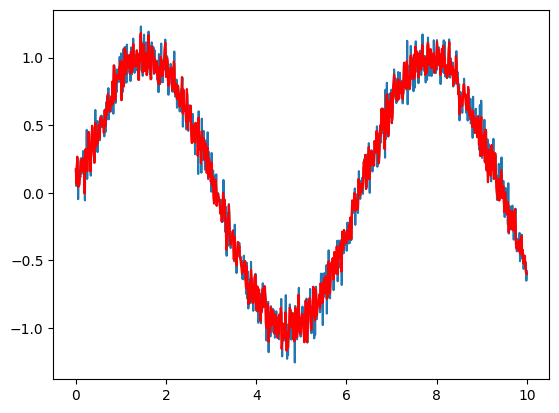

Estimated integral: 750126382192.586
Error estimate: 158698151570.65332


In [691]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.interpolate import BarycentricInterpolator
from scipy.integrate import quad

# Example parameters
a = 0  # Start of interval
b = 10  # End of interval
omega = 5  # Frequency of the oscillatory component
N = 1000  # Number of points

# Generating example data: g(x) as a noisy sine wave
np.random.seed(0)  # For reproducibility
x = np.linspace(a, b, N)
g_x = np.sin(x) + 0.1 * np.random.normal(size=N)  # Noisy sine wave


# Apply SavGol filter
g_x_smoothed = savgol_filter(g_x, window_length=4, polyorder=2)

# Use polynomial interpolation on the smoothed data
interpolator = BarycentricInterpolator(x, g_x_smoothed)
plt.plot(x, g_x)
plt.plot(x, g_x_smoothed, 'r-')
plt.plot(x, interpolator(x), 'r-')
plt.show()

# Define the function to integrate (g(x) * cos(omega x))
def integrand(x):
    return interpolator(x) * np.cos(omega * x)

# Perform the numerical integration
integral, error = quad(integrand, a, b, limit=10000)

print(f"Estimated integral: {integral}")
print(f"Error estimate: {error}")

In [704]:
def fourier_cos(f, dx, k=None, axis=0):
    """Calculate a direct fourier cosine transform of function f(x) using
    Filon's integration method

    k, F = fourier_cos(f, dx)
    Array values f[0]..f[2n] is expected to correspond to f(0.0)..f(2n*dx),
    hence, it should contain an odd number of elements.
    The transform is approximated with the integral
    2*\int_{0}^{xmax}
    where xmax = 2n*dx

    If k is not provided, linspace(0.0, 2*pi/dx, f.shape[axis]),
    will be used.
    """

    f = np.array([f(2*n*dx) for n in range(20)])
    if k is None:
        k = np.linspace(0.0, 2*pi/dx, f.shape[axis])

    return k, 2*cos_integral(f, dx, k, x0=0.0, axis=axis)


def cos_integral(f, dx, k, x0=0.0, axis=0):
    """\int_{x0}^{2n*dx} f(x)*cos(k x) dx

    f must have length 2n+1 along the integration axis.
    """
    return _gen_sc_int(f, dx, k, x0, axis, np.cos)

def sin_integral(f, dx, k, x0=0.0, axis=0):
    """\int_{x0}^{2n*dx} f(x)*sin(k x) dx

    f must have length 2n+1 along the integration axis.
    """
    return _gen_sc_int(f, dx, k, x0, axis, np.sin)

def _gen_sc_int(f, dx, k, x0, axis, sc):

    f = np.require(f)
    k = np.require(k)

    try:
        axis = range(f.ndim)[axis]
    except (IndexError, TypeError):
        print('Error: axis(=%s) is invalid' % str(axis))
        raise

    if k.ndim != 1:
        raise ValueError('k is not one dimensional')

    Nk = len(k)
    Nx = f.shape[axis]
    x_shape = [1]*f.ndim + [Nx] # We'll transpose axis and put it last
    k_shape = [1]*(f.ndim+1)    #
    k_shape[axis] = Nk          #

    if mod((Nx-1), 2) != 0 or Nx < 3:
        raise ValueError('f must have an odd length, >=3, along its integration axis')

    s = (slice(None),)*f.ndim
    odd_index =   s + (slice(1,None,2),)
    even_index =  s + (slice(0,None,2),)
    first_index = s + ((0,),)
    last_index =  s + ((-1,),)

    alpha, beta, gamma = [x.reshape(k_shape[:-1]) for x in _alpha_beta_gamma(dx*k)]
    x = (x0+dx*arange(0.0, Nx)).reshape(x_shape)
    k = k.reshape(k_shape)

    # Add an extra dimension to f, and transpose it to put the x-dimension at axis=-1
    t = range(f.ndim+1)
    t[axis], t[-1] = t[-1], t[axis]
    f = f.reshape(f.shape+(1,)).transpose(t)

    sc_k_x = sc(k*x)
    sc_k_x[first_index] *= 0.5
    sc_k_x[last_index] *= 0.5

    if sc == sin:
        return dx*(alpha * np.sum((f[first_index] * cos(k*x0) -
                                f[last_index]  * cos(k*x[last_index])), axis=-1) +
                   beta  * np.sum(f[even_index] * sc_k_x[even_index],      axis=-1) +
                   gamma * np.sum(f[odd_index]  * sc_k_x[odd_index],       axis=-1))

    elif sc == cos:
        return dx*(alpha * np.sum((f[last_index]  * sin(k*x[last_index]) -
                                   f[first_index] * sin(k*x0)),         axis=-1) +
                   beta  * np.sum(f[even_index] * sc_k_x[even_index],   axis=-1) +
                   gamma * np.sum(f[odd_index]  * sc_k_x[odd_index],    axis=-1))

    raise RuntimeError('Internal error, this should not happen')



def _alpha_beta_gamma(theta):
    # From theta, calculate alpha, beta, and gamma

    N = len(theta)
    alpha = np.zeros(N)
    beta = np.zeros(N)
    gamma = np.zeros(N)

    # theta==0 needs special treatment
    I_nz, = theta.nonzero()
    I_z, = np.where(theta==0.0)
    if len(I_z) > 0:
        beta[I_z] = 2.0/3.0
        gamma[I_z] = 4.0/3.0
        theta = theta[I_nz]

    sin_t = np.sin(theta)
    cos_t = np.cos(theta)
    sin2_t = sin_t*sin_t
    cos2_t = cos_t*cos_t
    theta2 = theta*theta
    itheta3 = 1.0/(theta2*theta)

    alpha[I_nz] = itheta3*(theta2 + theta*sin_t*cos_t - 2*sin2_t)
    beta[I_nz] = 2*itheta3*(theta*(1+cos2_t) - 2*sin_t*cos_t)
    gamma[I_nz] = 4*itheta3*(sin_t - theta*cos_t)

    return (alpha, beta, gamma)

In [ ]:
fourier_cos(f_prime, 0.01)

In [21]:
f = lambda x: -x**2 + 2*x
f_prime = lambda x: -2*x + 2

tspan = np.linspace(0, 20, 100)
T = tspan[-1]
s = np.arange(1, 50, 1.0).reshape((-1, 1))[:, :] # s = 1
funcs_input = np.pi * s @ tspan.reshape((1, -1)) / T
print(funcs_input.shape)
# print(tspan)
gs = np.sqrt(2 / T) * np.sin(funcs_input)
dgs = np.pi * s / T * np.sqrt(2 / T) * np.cos(funcs_input)

first = f_prime(tspan).reshape(-1,1) * gs[..., np.newaxis]
second = f(tspan).reshape(-1,1) * dgs[..., np.newaxis]
first = simpson(first, float(tspan[1] - tspan[0]), dim = 1)
second = simpson(second, float(tspan[1] - tspan[0]), dim = 1)

print(first, second)
print(first + second)
print(((first+second)**2).sum())

(49, 100)
tensor([-72.4741,  40.2634, -24.1580,  20.1317, -14.4949,  13.4213, -10.3536,
         10.0662,  -8.0532,   8.0534,  -6.5895,   6.7120,  -5.5768,   5.7545,
         -4.8349,   5.0373,  -4.2685,   4.4807,  -3.8227,   4.0369,  -3.4636,
          3.6758,  -3.1690,   3.3773,  -2.9241,   3.1275,  -2.7184,   2.9165,
         -2.5444,   2.7373,  -2.3965,   2.5843,  -2.2705,   2.4535,  -2.1630,
          2.3414,  -2.0712,   2.2454,  -1.9929,   2.1630,  -1.9260,   2.0922,
         -1.8687,   2.0311,  -1.8191,   1.9776,  -1.7756,   1.9301,  -1.7363],
       dtype=torch.float64) tensor([ 72.4741, -40.2634,  24.1580, -20.1317,  14.4948, -13.4213,  10.3540,
        -10.0670,   8.0551,  -8.0568,   6.5956,  -6.7211,   5.5908,  -5.7741,
          4.8624,  -5.0733,   4.3160,  -4.5394,   3.8962,  -4.1233,   3.5664,
         -3.7908,   3.2986,  -3.5136,   3.0677,  -3.2649,   2.8473,  -3.0158,
          2.6070,  -2.7324,   2.3108,  -2.3745,   1.9149,  -1.8937,   1.3673,
         -1.2331,   0.606

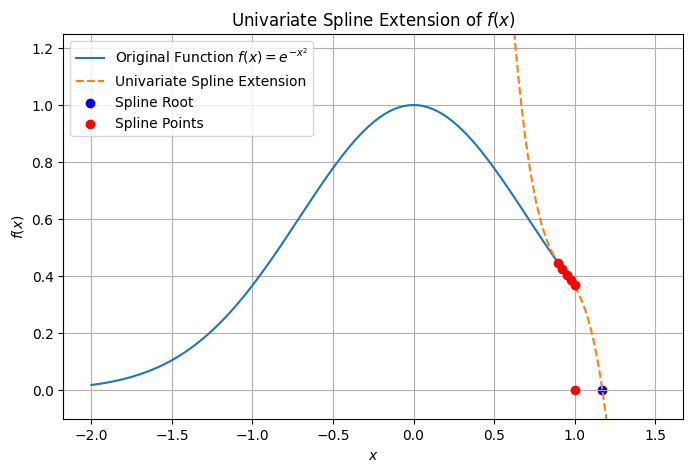

In [139]:
from scipy.interpolate import UnivariateSpline

# Define the function again
def f(x):
    return np.exp(-x**2)

# Choose a cutoff point and generate points
x_0 = 1
x = np.linspace(-2, x_0, 100)
y = f(x)

# Points near x_0 and synthetic point
x_near_x0 = np.linspace(x_0 - 0.1, x_0, 5)
y_near_x0 = f(x_near_x0)
eps = 1e-6  # Small distance beyond x_0
x_spline_points = np.append(x_near_x0, x_0 + eps)
y_spline_points = np.append(y_near_x0, 0)

# Fit a Univariate Spline
weights = np.ones(x_spline_points.shape)
weights[-1] = 0.1
us = UnivariateSpline(x_spline_points, y_spline_points, s=1e6, k=3,
                      w=weights)

from scipy.optimize import bisect

# We know the root should be near x_0 + eps, so we search in a small interval around this point
interval_start = x_0
us0_g0 = us(interval_start) > 0
for i in range(-6,6):
    interval_end = x_0 + eps + 2**i  # Slightly larger to ensure we encompass the root
    us1_g0 = us(interval_end) > 0
    if (us0_g0 and us1_g0) or (not us0_g0 and not us1_g0):
        continue
    else:
        pass
    
root_bisect = bisect(us, interval_start, interval_end)



# Plotting
x_extended = np.linspace(x_0 - 0.5, x_0 + eps+0.5, 100)
y_extended_us = us(x_extended)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Original Function $f(x) = e^{-x^2}$')
plt.plot(x_extended, y_extended_us, '--', label='Univariate Spline Extension')
plt.scatter([root_bisect], [0], color='b', label="Spline Root")
plt.scatter(x_spline_points, y_spline_points, color='red', zorder=5, label='Spline Points')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Univariate Spline Extension of $f(x)$')
plt.legend()
plt.ylim([-0.1, 1.25])
plt.grid(True)
plt.show()

In [38]:
us.roots()

array([], dtype=float64)

1.172846837825065